In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#trinity dataset

In [2]:
url="Downloads/trinity_formatted_release_v0.1.0.csv"
df = pd.read_csv(url, delimiter=",")

In [3]:
df.head

<bound method NDFrame.head of        user_ID  group_ID                submit_time  \
0           22        51  2016-02-02 06:53:00-07:00   
1           22        51  2016-02-02 06:53:52-07:00   
2           22        51  2016-02-02 07:36:35-07:00   
3           22        51  2016-02-02 08:07:19-07:00   
4           48        49  2016-02-02 12:25:13-07:00   
...        ...       ...                        ...   
25232        1         1  2016-04-21 23:13:17-06:00   
25233        1         1  2016-04-21 23:13:17-06:00   
25234        1         1  2016-04-21 23:13:17-06:00   
25235        1         1  2016-04-21 23:13:17-06:00   
25236        1         1  2016-04-21 23:13:17-06:00   

                      start_time              dispatch_time  \
0                            NaN                        NaN   
1                            NaN                        NaN   
2                            NaN                        NaN   
3                            NaN                        N

In [43]:
mean_nodes_per_status = df.groupby("job_status")["node_count"].mean()

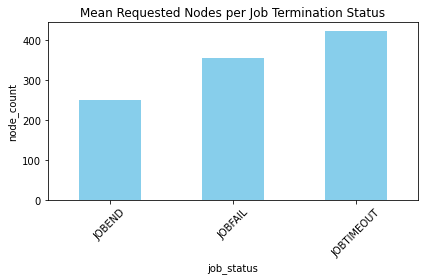

In [44]:
mean_nodes_per_status.plot(kind='bar', color='skyblue')
plt.xlabel("job_status")
plt.ylabel("node_count")
plt.title("Mean Requested Nodes per Job Termination Status")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [45]:
mean_tasks_per_status = df.groupby("job_status")["tasks_requested"].mean()

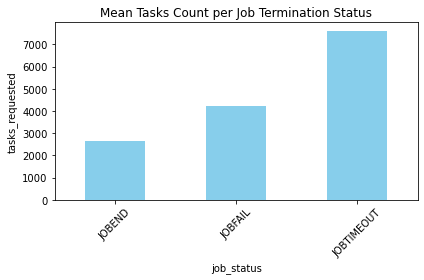

In [46]:
mean_tasks_per_status.plot(kind='bar', color='skyblue')
plt.xlabel("job_status")
plt.ylabel("tasks_requested")
plt.title("Mean Tasks Count per Job Termination Status")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
default_datetime = pd.to_datetime(0, unit='s') 
df['submit_time'].fillna(default_datetime, inplace=True)
df['start_time'].fillna(default_datetime, inplace=True)
df['queue_time'].fillna(default_datetime, inplace=True)

df['timesub_numeric'] = pd.to_datetime(df['submit_time']).apply(lambda x: x.timestamp())  
df['timesta_numeric'] = pd.to_datetime(df['start_time']).apply(lambda x: x.timestamp())  
df['timeque_numeric'] = pd.to_datetime(df['queue_time']).apply(lambda x: x.timestamp()) 

X = df[['user_ID', 'group_ID', 'node_count', 'tasks_requested', 'timesub_numeric', 'timesta_numeric', 'timeque_numeric']]
y = df['job_status']  

X_filtered = X[y.isin(['JOBFAIL', 'JOBEND', 'JOBTIMEOUT'])]

y_filtered = y[y.isin(['JOBFAIL', 'JOBEND', 'JOBTIMEOUT'])]

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_encoded)

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_resampled, y_train_resampled, epochs=50, batch_size=32, validation_split=0.2)

loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

Epoch 1/50
1356/1356 [==============================] - 11s 7ms/step - loss: 0.8333 - accuracy: 0.6315 - val_loss: 1.9010 - val_accuracy: 0.0000e+00
Epoch 2/50
1356/1356 [==============================] - 9s 7ms/step - loss: 0.7480 - accuracy: 0.6696 - val_loss: 2.0045 - val_accuracy: 0.0000e+00
Epoch 3/50
1356/1356 [==============================] - 9s 7ms/step - loss: 0.7206 - accuracy: 0.6866 - val_loss: 2.0205 - val_accuracy: 0.0000e+00
Epoch 4/50
1356/1356 [==============================] - 9s 7ms/step - loss: 0.7037 - accuracy: 0.6939 - val_loss: 2.0069 - val_accuracy: 0.0000e+00
Epoch 5/50
1356/1356 [==============================] - 9s 6ms/step - loss: 0.7007 - accuracy: 0.6975 - val_loss: 2.0804 - val_accuracy: 0.0000e+00
Epoch 6/50
1356/1356 [==============================] - 9s 7ms/step - loss: 0.6936 - accuracy: 0.6971 - val_loss: 1.9689 - val_accuracy: 0.0000e+00
Epoch 7/50
1356/1356 [==============================] - 9s 7ms/step - loss: 0.6881 - accuracy: 0.7003 - val_los

AttributeError: 'Sequential' object has no attribute 'predict_classes'

In [39]:
import numpy as np

loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_encoded, y_pred))


158/158 [==============================] - 1s 3ms/step - loss: 0.6538 - accuracy: 0.6502
Test Loss: 0.6538099646568298, Test Accuracy: 0.6501584649085999
              precision    recall  f1-score   support

           0       0.17      0.83      0.28       260
           1       0.94      0.62      0.75      3365
           2       0.63      0.93      0.75      1051
           3       0.89      0.02      0.04       372

    accuracy                           0.65      5048
   macro avg       0.66      0.60      0.46      5048
weighted avg       0.83      0.65      0.67      5048



In [42]:
from tensorflow.keras.layers import BatchNormalization

# Build the model
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(4, activation='softmax')
])

# Compile the model with a lower learning rate
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train_encoded, epochs=100, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")


Epoch 1/100
505/505 [==============================] - 9s 11ms/step - loss: 0.6556 - accuracy: 0.7735 - val_loss: 0.5798 - val_accuracy: 0.8187
Epoch 2/100
505/505 [==============================] - 4s 9ms/step - loss: 0.5336 - accuracy: 0.8151 - val_loss: 0.5245 - val_accuracy: 0.8294
Epoch 3/100
505/505 [==============================] - 4s 9ms/step - loss: 0.5210 - accuracy: 0.8196 - val_loss: 0.5346 - val_accuracy: 0.8180
Epoch 4/100
505/505 [==============================] - 4s 9ms/step - loss: 0.5038 - accuracy: 0.8261 - val_loss: 0.5044 - val_accuracy: 0.8284
Epoch 5/100
505/505 [==============================] - 4s 9ms/step - loss: 0.5021 - accuracy: 0.8248 - val_loss: 0.5080 - val_accuracy: 0.8289
Epoch 6/100
505/505 [==============================] - 4s 9ms/step - loss: 0.4991 - accuracy: 0.8265 - val_loss: 0.5105 - val_accuracy: 0.8242
Epoch 7/100
505/505 [==============================] - 4s 9ms/step - loss: 0.4982 - accuracy: 0.8273 - val_loss: 0.5015 - val_accuracy: 0.825

Epoch 58/100
505/505 [==============================] - 4s 9ms/step - loss: 0.4338 - accuracy: 0.8423 - val_loss: 0.4547 - val_accuracy: 0.8361
Epoch 59/100
505/505 [==============================] - 4s 9ms/step - loss: 0.4332 - accuracy: 0.8438 - val_loss: 0.4582 - val_accuracy: 0.8393
Epoch 60/100
505/505 [==============================] - 4s 9ms/step - loss: 0.4300 - accuracy: 0.8442 - val_loss: 0.4585 - val_accuracy: 0.8328
Epoch 61/100
505/505 [==============================] - 4s 9ms/step - loss: 0.4332 - accuracy: 0.8417 - val_loss: 0.4552 - val_accuracy: 0.8380
Epoch 62/100
505/505 [==============================] - 4s 9ms/step - loss: 0.4320 - accuracy: 0.8435 - val_loss: 0.4579 - val_accuracy: 0.8356
Epoch 63/100
505/505 [==============================] - 4s 9ms/step - loss: 0.4330 - accuracy: 0.8408 - val_loss: 0.4525 - val_accuracy: 0.8415
Epoch 64/100
505/505 [==============================] - 4s 9ms/step - loss: 0.4317 - accuracy: 0.8429 - val_loss: 0.4617 - val_accuracy:

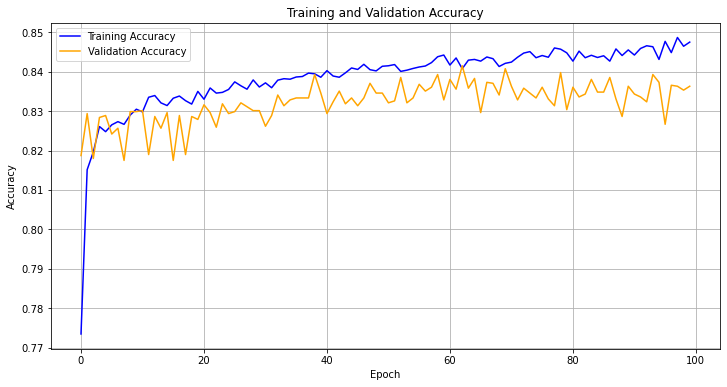

In [43]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
import numpy as np

loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_encoded, y_pred))

158/158 [==============================] - 1s 4ms/step - loss: 0.4268 - accuracy: 0.8405
Test Loss: 0.42676597833633423, Test Accuracy: 0.8405309319496155
              precision    recall  f1-score   support

           0       0.62      0.33      0.43       260
           1       0.83      0.98      0.89      3365
           2       1.00      0.69      0.82      1051
           3       0.72      0.39      0.51       372

    accuracy                           0.84      5048
   macro avg       0.79      0.60      0.66      5048
weighted avg       0.84      0.84      0.83      5048



In [53]:
class_weight_dict = {
    0: 1,  # Increase weight for class 0
    1: 1, 
    2: 1, 
    3: 2   # Increase weight for class 3
}

history = model.fit(X_train_scaled, y_train_encoded, epochs=100, batch_size=32, validation_split=0.2, class_weight=class_weight_dict)

loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

Epoch 1/100
505/505 [==============================] - 9s 12ms/step - loss: 0.5474 - accuracy: 0.8189 - val_loss: 0.4703 - val_accuracy: 0.8224
Epoch 2/100
505/505 [==============================] - 6s 12ms/step - loss: 0.5188 - accuracy: 0.8323 - val_loss: 0.4598 - val_accuracy: 0.8299
Epoch 3/100
505/505 [==============================] - 6s 12ms/step - loss: 0.5147 - accuracy: 0.8357 - val_loss: 0.4741 - val_accuracy: 0.8341
Epoch 4/100
505/505 [==============================] - 6s 12ms/step - loss: 0.5139 - accuracy: 0.8350 - val_loss: 0.4556 - val_accuracy: 0.8323
Epoch 5/100
505/505 [==============================] - 6s 12ms/step - loss: 0.5127 - accuracy: 0.8378 - val_loss: 0.4605 - val_accuracy: 0.8239
Epoch 6/100
505/505 [==============================] - 6s 12ms/step - loss: 0.5170 - accuracy: 0.8346 - val_loss: 0.4588 - val_accuracy: 0.8264
Epoch 7/100
505/505 [==============================] - 6s 12ms/step - loss: 0.5134 - accuracy: 0.8352 - val_loss: 0.4731 - val_accuracy:

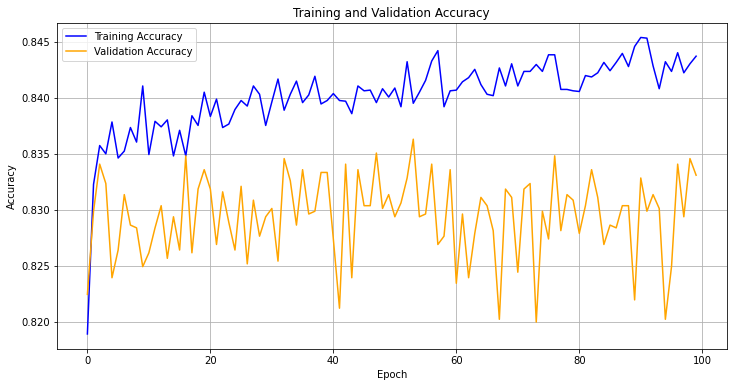

In [54]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [55]:
import numpy as np

loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_encoded, y_pred))

158/158 [==============================] - 1s 5ms/step - loss: 0.4192 - accuracy: 0.8427
Test Loss: 0.41919395327568054, Test Accuracy: 0.8427099585533142
              precision    recall  f1-score   support

           0       0.66      0.38      0.49       260
           1       0.85      0.95      0.90      3365
           2       1.00      0.69      0.82      1051
           3       0.57      0.66      0.61       372

    accuracy                           0.84      5048
   macro avg       0.77      0.67      0.70      5048
weighted avg       0.85      0.84      0.84      5048



In [16]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import BatchNormalization

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(sampling_strategy='minority')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_encoded)

model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(4, activation='softmax')
])

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_resampled, y_train_resampled, epochs=100, batch_size=32, validation_split=0.2)

loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

Epoch 1/100
819/819 [==============================] - 12s 10ms/step - loss: 0.7871 - accuracy: 0.6907 - val_loss: 0.7250 - val_accuracy: 0.7624
Epoch 2/100
819/819 [==============================] - 7s 9ms/step - loss: 0.6934 - accuracy: 0.7173 - val_loss: 0.7770 - val_accuracy: 0.6268
Epoch 3/100
819/819 [==============================] - 7s 9ms/step - loss: 0.6690 - accuracy: 0.7308 - val_loss: 0.6816 - val_accuracy: 0.7334
Epoch 4/100
819/819 [==============================] - 7s 9ms/step - loss: 0.6520 - accuracy: 0.7357 - val_loss: 0.7412 - val_accuracy: 0.6587
Epoch 5/100
819/819 [==============================] - 7s 9ms/step - loss: 0.6423 - accuracy: 0.7381 - val_loss: 0.6763 - val_accuracy: 0.6688
Epoch 6/100
819/819 [==============================] - 7s 9ms/step - loss: 0.6310 - accuracy: 0.7426 - val_loss: 0.6356 - val_accuracy: 0.7534
Epoch 7/100
819/819 [==============================] - 7s 9ms/step - loss: 0.6220 - accuracy: 0.7465 - val_loss: 0.6661 - val_accuracy: 0.74

Epoch 58/100
819/819 [==============================] - 7s 9ms/step - loss: 0.5286 - accuracy: 0.7883 - val_loss: 0.5560 - val_accuracy: 0.7268
Epoch 59/100
819/819 [==============================] - 7s 9ms/step - loss: 0.5278 - accuracy: 0.7864 - val_loss: 0.6715 - val_accuracy: 0.6621
Epoch 60/100
819/819 [==============================] - 7s 9ms/step - loss: 0.5257 - accuracy: 0.7902 - val_loss: 0.4963 - val_accuracy: 0.8155
Epoch 61/100
819/819 [==============================] - 7s 9ms/step - loss: 0.5258 - accuracy: 0.7888 - val_loss: 0.4993 - val_accuracy: 0.7958
Epoch 62/100
819/819 [==============================] - 7s 9ms/step - loss: 0.5233 - accuracy: 0.7889 - val_loss: 0.5607 - val_accuracy: 0.7683
Epoch 63/100
819/819 [==============================] - 7s 9ms/step - loss: 0.5248 - accuracy: 0.7895 - val_loss: 0.5118 - val_accuracy: 0.8196
Epoch 64/100
819/819 [==============================] - 7s 9ms/step - loss: 0.5224 - accuracy: 0.7906 - val_loss: 0.5129 - val_accuracy:

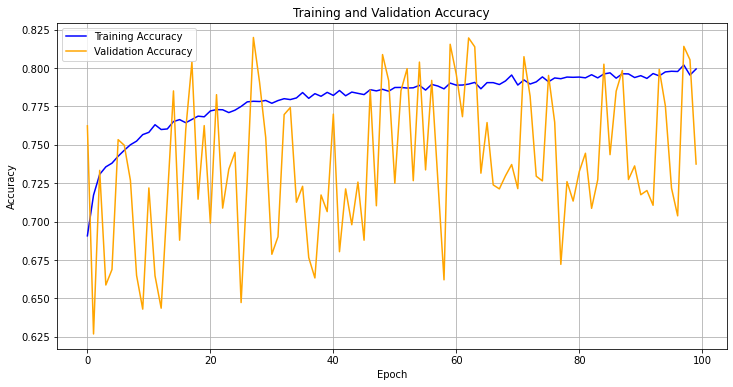

In [17]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import numpy as np
from sklearn.metrics import classification_report

loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_encoded, y_pred))

158/158 [==============================] - 1s 4ms/step - loss: 0.5051 - accuracy: 0.8130
Test Loss: 0.505099892616272, Test Accuracy: 0.8129952549934387
              precision    recall  f1-score   support

           0       0.31      0.67      0.43       260
           1       0.85      0.92      0.88      3365
           2       1.00      0.69      0.82      1051
           3       0.78      0.31      0.45       372

    accuracy                           0.81      5048
   macro avg       0.74      0.65      0.64      5048
weighted avg       0.85      0.81      0.81      5048



In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_scaled, y_train_encoded)

y_pred_rf = rf_classifier.predict(X_test_scaled)
print("Random Forest Classifier:")
print(classification_report(y_test_encoded, y_pred_rf))

num_estimators = 5
ensemble = []
for i in range(num_estimators):
    rf = RandomForestClassifier(n_estimators=100, random_state=i)
    rf.fit(X_train_scaled, y_train_encoded)
    ensemble.append(rf)

y_pred_ensemble = np.mean([rf.predict(X_test_scaled) for rf in ensemble], axis=0).astype(int)
print("Ensemble of Random Forests:")
print(classification_report(y_test_encoded, y_pred_ensemble))

Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.74      0.68      0.71       260
           1       0.91      0.93      0.92      3365
           2       0.87      0.83      0.85      1051
           3       0.75      0.69      0.72       372

    accuracy                           0.88      5048
   macro avg       0.82      0.78      0.80      5048
weighted avg       0.88      0.88      0.88      5048

Ensemble of Random Forests:
              precision    recall  f1-score   support

           0       0.73      0.70      0.72       260
           1       0.90      0.94      0.92      3365
           2       0.87      0.82      0.84      1051
           3       0.78      0.66      0.71       372

    accuracy                           0.88      5048
   macro avg       0.82      0.78      0.80      5048
weighted avg       0.88      0.88      0.88      5048



In [14]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.svm import SVC

class_mapping = {'JOBEND': 0, 'JOBFAIL': 1, 'JOBTIMEOUT': 2}
y_train_encoded = [class_mapping[label] for label in y_train]
y_test_encoded = [class_mapping[label] for label in y_test]

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
]

stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stacking_classifier.fit(X_train_scaled, y_train_encoded)

y_pred_stacking = stacking_classifier.predict(X_test_scaled)

inverse_class_mapping = {v: k for k, v in class_mapping.items()}
y_test_original = [inverse_class_mapping[label] for label in y_test_encoded]
y_pred_original = [inverse_class_mapping[label] for label in y_pred_stacking]

print("Stacking Classifier:")
print(classification_report(y_test_original, y_pred_original))

C:\Users\hp\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Stacking Classifier:
              precision    recall  f1-score   support

      JOBEND       0.91      0.96      0.93      3371
     JOBFAIL       0.91      0.80      0.85      1065
  JOBTIMEOUT       0.79      0.67      0.73       362

    accuracy                           0.90      4798
   macro avg       0.87      0.81      0.84      4798
weighted avg       0.90      0.90      0.90      4798



In [20]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test_encoded, y_pred_stacking)
print("Accuracy of Stacking classifier in Trinity trace:", accuracy)

Accuracy of Stacking classifier in Trinity trace: 0.9012088370154231


In [5]:
import joblib
mod=joblib.load('trinity_model_1.joblib')
predicted_labels=mod.predict(X_test_scaled)

In [7]:
class_mapping = {'JOBEND': 0, 'JOBFAIL': 1, 'JOBTIMEOUT': 2}
inverse_class_mapping = {v: k for k, v in class_mapping.items()}
predicted_labels = [inverse_class_mapping[label] for label in predicted_labels]

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have your true labels and predicted labels
true_labels = y_test

# Calculate precision
precision = precision_score(true_labels, predicted_labels, average='weighted')

# Calculate recall
recall = recall_score(true_labels, predicted_labels, average='weighted')

# Calculate F1 score
f1 = f1_score(true_labels, predicted_labels, average='weighted')

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.8998726654480096
Recall: 0.9012088370154231
F1 Score: 0.8989543759091777


In [13]:
import joblib
joblib.dump(stacking_classifier, 'pred_model.joblib')

['pred_model.joblib']

In [14]:
import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2  
  
k_best = SelectKBest(score_func=chi2, k=5)  

X_selected = k_best.fit_transform(X, y)

selected_indices = k_best.get_support(indices=True)

selected_features = X.columns[selected_indices]

print("Selected features:", selected_features)


Selected features: Index(['node_count', 'tasks_requested', 'timesub_numeric', 'timesta_numeric',
       'timeque_numeric'],
      dtype='object')


In [15]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression  

estimator = LogisticRegression()  

rfe = RFE(estimator, n_features_to_select=5)  

rfe.fit(X, y)

selected_indices = rfe.support_

selected_features = X.columns[selected_indices]

print("Selected features:", selected_features)


Selected features: Index(['node_count', 'tasks_requested', 'timesub_numeric', 'timesta_numeric',
       'timeque_numeric'],
      dtype='object')


In [16]:
from scipy.stats import f_oneway

category_1_data = df[df['job_status'] == 'JOBEND']['node_count']
category_2_data = df[df['job_status'] == 'JOBFAIL']['node_count']
category_3_data = df[df['job_status'] == 'JOBTIMEOUT']['node_count']

f_statistic, p_value = f_oneway(category_1_data, category_2_data,category_3_data)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

alpha = 0.05  
if p_value < alpha:
    print("The means of the node count are significantly different across job statuses.")
else:
    print("There is no significant difference in the means of the node count across job statuses.")


F-statistic: 31.98226953872671
p-value: 1.345136762436484e-14
The means of the node count are significantly different across job statuses.


In [17]:
from scipy.stats import f_oneway

category_1_data = df[df['job_status'] == 'JOBEND']['tasks_requested']
category_2_data = df[df['job_status'] == 'JOBFAIL']['tasks_requested']
category_3_data = df[df['job_status'] == 'JOBTIMEOUT']['tasks_requested']

f_statistic, p_value = f_oneway(category_1_data, category_2_data,category_3_data)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

alpha = 0.05  
if p_value < alpha:
    print("The means of the task requested are significantly different across job statuses.")
else:
    print("There is no significant difference in the means of the task requested across job statuses.")


F-statistic: 56.585767476631425
p-value: 3.040282501207475e-25
The means of the task requested are significantly different across job statuses.


In [18]:
from scipy.stats import kruskal

group1 = df[df['job_status'] == 'JOBFAIL']['tasks_requested']
group2 = df[df['job_status'] == 'JOBEND']['tasks_requested']
group3 = df[df['job_status'] == 'JOBTIMEOUT']['tasks_requested']

statistic, p_value = kruskal(group1, group2, group3)

print("Kruskal-Wallis Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: There are significant differences between groups.")
else:
    print("Fail to reject the null hypothesis: There are no significant differences between groups.")


Kruskal-Wallis Statistic: 800.2180089108516
P-value: 1.7173831803508512e-174
Reject the null hypothesis: There are significant differences between groups.


In [19]:
from scipy.stats import kruskal

group1 = df[df['job_status'] == 'JOBFAIL']['node_count']
group2 = df[df['job_status'] == 'JOBEND']['node_count']
group3 = df[df['job_status'] == 'JOBTIMEOUT']['node_count']

statistic, p_value = kruskal(group1, group2, group3)

print("Kruskal-Wallis Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: There are significant differences between groups.")
else:
    print("Fail to reject the null hypothesis: There are no significant differences between groups.")


Kruskal-Wallis Statistic: 327.4781458395567
P-value: 7.745048808555895e-72
Reject the null hypothesis: There are significant differences between groups.


In [20]:
from scipy.stats import mannwhitneyu

group1 = df[df['job_status'] == 'JOBFAIL']['tasks_requested']

group2 = df[df['job_status'] != 'JOBFAIL']['tasks_requested']

statistic, p_value = mannwhitneyu(group1, group2)

print("Mann-Whitney U Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the distribution of numerical values between the specified category and other categories.")


Mann-Whitney U Statistic: 47399355.5
P-value: 6.209624873063919e-26
Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.


In [21]:
from scipy.stats import mannwhitneyu

group1 = df[df['job_status'] == 'JOBFAIL']['node_count']

group2 = df[df['job_status'] != 'JOBFAIL']['node_count']

statistic, p_value = mannwhitneyu(group1, group2)

print("Mann-Whitney U Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the distribution of numerical values between the specified category and other categories.")


Mann-Whitney U Statistic: 48258331.0
P-value: 1.9177801597774632e-18
Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.


In [25]:
import numpy as np

def find_optimal_numerical_value(df, row_index, numerical_column, decision_tree_model, target_category='JOBEND', max_iter=100):
    current_numerical_value = df.loc[row_index, numerical_column]
    
    lower_bound = 0
    upper_bound = 298752  
    
    for _ in range(max_iter):
        midpoint = (lower_bound + upper_bound) / 2
        
        df.loc[row_index, numerical_column] = midpoint
        
        predicted_category = decision_tree_model.predict(df.loc[[row_index]])[0]
        
        if predicted_category == target_category:
            return midpoint  
        
        if predicted_category < target_category:
            lower_bound = midpoint
        else:
            upper_bound = midpoint
    
    return None

optimal_numerical_value = find_optimal_numerical_value(xx, 150, 'tasks_requested', decision_tree_model)
if optimal_numerical_value is not None:
    print("Optimal numerical value:", optimal_numerical_value)
else:
    print("Target category could not be reached within the specified number of iterations.")


Optimal numerical value: 149376.0


C:\Users\hp\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\hp\anaconda3\lib\site-packages\pandas\core\indexing.py:723: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value, self.name)


In [71]:
def predict_category_with_optimal_value(df, row_index, numerical_column, decision_tree_model, optimal_numerical_value):
    df.loc[row_index, numerical_column] = optimal_numerical_value
    predicted_category = decision_tree_model.predict(df.loc[[row_index]])[0]
    
    return predicted_category

# Example usage:
predicted_category = predict_category_with_optimal_value(xx, 8876, 'node_count', decision_tree_model, 256)
print("Predicted category with optimal value:", predicted_category)


Predicted category with optimal value: JOBEND


C:\Users\hp\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\hp\anaconda3\lib\site-packages\pandas\core\indexing.py:723: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value, self.name)


In [5]:
XX = df[['user_ID', 'group_ID', 'node_count', 'tasks_requested', 'timesub_numeric', 'timesta_numeric', 'timeque_numeric','job_status']]
yy = df['job_status']  
XX_filtered = XX[yy.isin(['JOBFAIL', 'JOBEND', 'JOBTIMEOUT'])]

In [26]:
y_pred = stacking_classifier.predict(X)

In [32]:
X_predicted_as_jobfail = X[y_pred == 'JOBFAIL']
X_predicted_as_jobfail_original = scaler.inverse_transform(X_predicted_as_jobfail)
fail_rows = pd.DataFrame(X_predicted_as_jobfail_original, columns=X.columns)
task_values_column = fail_rows['tasks_requested']
node_values_column = fail_rows['node_count']

In [33]:
#fail_rows = XX_filtered[XX_filtered['job_status'] == 'JOBFAIL']
#task_values_column = fail_rows['tasks_requested']

In [34]:
#fail_rows_node = XX_filtered[XX_filtered['job_status'] == 'JOBFAIL']
#node_values_column = fail_rows['node_count']

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd


X = X_filtered[['tasks_requested']]
y = y_filtered

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7090454355981659


In [17]:
import joblib
joblib.dump(clf, 'tasktree.joblib')#tasks

['tasktree.joblib']

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd


X = X_filtered[['node_count']]
y = y_filtered

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7080033347228012


In [19]:
import joblib
joblib.dump(clf, 'nodetree.joblib')#node

['nodetree.joblib']

In [56]:
def find_nearest_value_for_jobend(current_value, decision_tree):
    nearest_value = None
    min_distance = float('inf')
    
    def traverse_tree(node):
        nonlocal nearest_value, min_distance
        
        if decision_tree.tree_.children_left[node] == decision_tree.tree_.children_right[node]:
            if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'JOBEND':
                threshold_value = decision_tree.tree_.threshold[node]
                distance = abs(current_value - threshold_value)
                if distance < min_distance:
                    nearest_value = threshold_value
                    min_distance = distance
            return
        
        feature_index = decision_tree.tree_.feature[node]
        threshold_value = decision_tree.tree_.threshold[node]
        
        if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'JOBEND':
            if current_value <= threshold_value:
                traverse_tree(decision_tree.tree_.children_left[node])
            else:
                traverse_tree(decision_tree.tree_.children_right[node])
        
        distance = abs(current_value - threshold_value)
        if distance < min_distance:
            nearest_value = threshold_value
            min_distance = distance
    
    traverse_tree(0)
    
    return nearest_value


In [57]:
all_ranges = {status: [] for status in XX_filtered['job_status'].unique()}

df_sorted = XX_filtered.sort_values(by='tasks_requested')

prev_status = None
prev_task_count = None
for task_count, job_status in zip(df_sorted['tasks_requested'], df_sorted['job_status']):
    if prev_status is not None and job_status != prev_status:
        all_ranges[prev_status].append((prev_task_count, task_count))
    prev_status = job_status
    prev_task_count = task_count

merged_ranges = {status: [ranges[0]] for status, ranges in all_ranges.items()}
for status, ranges in all_ranges.items():
    for r in ranges[1:]:
        if r[1] == merged_ranges[status][-1][1]:
            merged_ranges[status][-1] = (merged_ranges[status][-1][0], r[1])
        else:
            merged_ranges[status].append(r)
            
fail_range = merged_ranges['JOBFAIL']
end_range = merged_ranges['JOBEND']
def calculate_threshold(range_list):
    thresholds = []
    for start, end in range_list:
        threshold = (start + end) / 2
        thresholds.append(threshold)
    return thresholds

fail_thresholds = calculate_threshold(fail_range)

end_thresholds = calculate_threshold(end_range)
def find_nearest_threshold(value, thresholds, used_thresholds):
    min_distance = float('inf')
    nearest_threshold = None
    
    available_thresholds = [t for t in thresholds if t not in used_thresholds]
    
    if not available_thresholds:
        return None
    
    available_thresholds.sort(key=lambda x: abs(value - x))
    
    for threshold in available_thresholds:
        distance = abs(value - threshold)
        
        if distance < min_distance:
            min_distance = distance
            nearest_threshold = threshold
    
    used_thresholds.append(nearest_threshold)
    
    if nearest_threshold > value:
        lower_thresholds = [t for t in available_thresholds if t < value]
        if lower_thresholds:
            nearest_threshold = max(lower_thresholds)
            used_thresholds.append(nearest_threshold)
    
    return nearest_threshold

In [58]:
def predict_category_with_optimal_value(df, row_index, numerical_column, decision_tree_model, optimal_numerical_value):
    df_clean = df.dropna()
    df_clean.loc[row_index, numerical_column] = optimal_numerical_value    
    predicted_category = decision_tree_model.predict(df_clean.loc[[row_index]])[0]
    
    return predicted_category


In [59]:
optimal_decision_tree_model = joblib.load('tasktree.joblib')
prediction_model = joblib.load('pred_model.joblib')

In [60]:
def find_optimal_value_to_reach_finish(values_column, optimal_decision_tree_model, prediction_model, thresholds, max_iterations):
    optimal_values = []
    used_thresholds = []
    for index, value_to_find in values_column.iteritems():
        if pd.isnull(value_to_find):
            continue
        
        iterations = 0
        current_value = value_to_find
        while iterations < max_iterations:
            nearest_value_tree = find_nearest_value_for_jobend(current_value, optimal_decision_tree_model)
            if nearest_value_tree is not None:
                current_value = nearest_value_tree
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(X_filtered, index, 'tasks_requested', prediction_model, nearest_value_tree)
                if predicted_category == 'JOBEND':
                    optimal_values.append(current_value)
                    break
            
            nearest_threshold = find_nearest_threshold(current_value, thresholds, used_thresholds)
            if nearest_threshold != current_value:
                current_value = nearest_threshold
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(X_filtered, index, 'tasks_requested', prediction_model, nearest_threshold)
                if predicted_category == 'JOBEND':
                    optimal_values.append(current_value)
                    break
            
            iterations += 1

    return optimal_values

used_thresholds = []

optimal_values = find_optimal_value_to_reach_finish(task_values_column, optimal_decision_tree_model, prediction_model, end_thresholds, 300) 
if optimal_values:
    print("Number of optimal values found:", len(optimal_values))

Number of optimal values found: 661


In [53]:
all_ranges = {status: [] for status in XX_filtered['job_status'].unique()}

df_sorted = XX_filtered.sort_values(by='node_count')

prev_status = None
prev_node_count = None
for node_count, job_status in zip(df_sorted['node_count'], df_sorted['job_status']):
    if prev_status is not None and job_status != prev_status:
        all_ranges[prev_status].append((prev_node_count, node_count))
    prev_status = job_status
    prev_node_count = node_count

merged_ranges = {status: [ranges[0]] for status, ranges in all_ranges.items()}
for status, ranges in all_ranges.items():
    for r in ranges[1:]:
        if r[1] == merged_ranges[status][-1][1]:
            merged_ranges[status][-1] = (merged_ranges[status][-1][0], r[1])
        else:
            merged_ranges[status].append(r)
            
fail_range = merged_ranges['JOBFAIL']
end_range = merged_ranges['JOBEND']
def calculate_threshold(range_list):
    thresholds = []
    for start, end in range_list:
        threshold = (start + end) / 2
        thresholds.append(threshold)  
    return thresholds

fail_thresholds = calculate_threshold(fail_range)

end_thresholds = calculate_threshold(end_range)
def find_nearest_threshold(value, thresholds, used_thresholds):
    min_distance = float('inf')
    nearest_threshold = None
    
    available_thresholds = [t for t in thresholds if t not in used_thresholds]
    
    if not available_thresholds:
        return None
    
    available_thresholds.sort(key=lambda x: abs(value - x))
    
    for threshold in available_thresholds:
        distance = abs(value - threshold)
        
        if distance < min_distance:
            min_distance = distance
            nearest_threshold = threshold
    
    used_thresholds.append(nearest_threshold)
    
    if nearest_threshold > value:
        lower_thresholds = [t for t in available_thresholds if t < value]
        if lower_thresholds:
            nearest_threshold = max(lower_thresholds)  
            used_thresholds.append(nearest_threshold)
    
    return nearest_threshold

In [54]:
optimal_decision_tree_model = joblib.load('nodetree.joblib')
prediction_model = joblib.load('pred_model.joblib')

In [55]:
def find_optimal_value_to_reach_finish(values_column, optimal_decision_tree_model, prediction_model, thresholds, max_iterations):
    optimal_values = []
    used_thresholds = []
    for index, value_to_find in values_column.iteritems():
        if pd.isnull(value_to_find):
            continue
        
        iterations = 0
        current_value = value_to_find
        while iterations < max_iterations:
            nearest_value_tree = find_nearest_value_for_jobend(current_value, optimal_decision_tree_model)
            if nearest_value_tree is not None:
                current_value = nearest_value_tree
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(X_filtered, index, 'node_count', prediction_model, nearest_value_tree)
                if predicted_category == 'JOBEND':
                    optimal_values.append(current_value)
                    break
            
            nearest_threshold = find_nearest_threshold(current_value, thresholds, used_thresholds)
            if nearest_threshold != current_value:
                current_value = nearest_threshold
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(X_filtered, index, 'node_count', prediction_model, nearest_threshold)
                if predicted_category == 'JOBEND':
                    optimal_values.append(current_value)
                    break
            
            iterations += 1

    return optimal_values

used_thresholds = []

optimal_values = find_optimal_value_to_reach_finish(node_values_column, optimal_decision_tree_model, prediction_model, end_thresholds, 300) 
if optimal_values:
    print("Number of optimal values found:", len(optimal_values))

Number of optimal values found: 661


In [6]:
fail_rows=XX_filtered[XX_filtered['job_status'] == 'JOBFAIL']

In [7]:
def preprocess_data(XX_filtered):
    end_range_tasks_requested = calculate_ranges(XX_filtered, 'tasks_requested')['JOBEND']
    
    end_range_node_count = calculate_ranges(XX_filtered, 'node_count')['JOBEND']
    
    return {
        'tasks_requested': {
            'end_range': end_range_tasks_requested
        },
        'node_count': {
            'end_range': end_range_node_count
        }
    }

def calculate_ranges(data, feature):
    all_ranges = {status: [] for status in data['job_status'].unique()}
    df_sorted = data.sort_values(by=feature)
    prev_status = None
    prev_value = None
    
    for value, status in zip(df_sorted[feature], df_sorted['job_status']):
        if prev_status is not None and status != prev_status:
            all_ranges[prev_status].append((prev_value, value))
        prev_status = status
        prev_value = value
    
    merged_ranges = {status: [ranges[0]] for status, ranges in all_ranges.items()}
    for status, ranges in all_ranges.items():
        for r in ranges[1:]:
            if r[1] == merged_ranges[status][-1][1]:
                merged_ranges[status][-1] = (merged_ranges[status][-1][0], r[1])
            else:
                merged_ranges[status].append(r)
    
    return merged_ranges


ranges_data = preprocess_data(XX_filtered)

end_range_tasks_requested = ranges_data['tasks_requested']['end_range']
end_range_node_count = ranges_data['node_count']['end_range']

def calculate_threshold(range_list):
    thresholds = []
    for start, end in range_list:
        threshold = int((start + end) / 2)
        thresholds.append(threshold)  
    return thresholds

end_thresholds_node_count = calculate_threshold(end_range_node_count)
end_thresholds_tasks_requested = calculate_threshold(end_range_tasks_requested)

In [54]:
import random
import joblib
import pandas as pd


def find_nearest_value_for_jobend(current_value, decision_tree):
    nearest_value = None
    min_distance = float('inf')
    
    def traverse_tree(node):
        nonlocal nearest_value, min_distance
        
        if decision_tree.tree_.children_left[node] == decision_tree.tree_.children_right[node]:
            if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'JOBEND':
                threshold_value = decision_tree.tree_.threshold[node]
                distance = abs(current_value - threshold_value)
                if distance < min_distance:
                    nearest_value = threshold_value
                    min_distance = distance
            return
        
        feature_index = decision_tree.tree_.feature[node]
        threshold_value = decision_tree.tree_.threshold[node]
        
        if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'JOBEND':
            if current_value <= threshold_value:
                traverse_tree(decision_tree.tree_.children_left[node])
            else:
                traverse_tree(decision_tree.tree_.children_right[node])
        
        distance = abs(current_value - threshold_value)
        if distance < min_distance:
            nearest_value = threshold_value
            min_distance = distance
    
    traverse_tree(0)
    
    return int(nearest_value)






def find_nearest_threshold(value, thresholds, used_thresholds):
    min_distance = float('inf')
    nearest_threshold = None
    
    available_thresholds = [t for t in thresholds if t not in used_thresholds]
    
    if not available_thresholds:
        return None
    
    available_thresholds.sort(key=lambda x: abs(value - x))
    
    for threshold in available_thresholds:
        distance = abs(value - threshold)
        
        if distance < min_distance:
            min_distance = distance
            nearest_threshold = threshold
    
    used_thresholds.append(nearest_threshold)
    
    if nearest_threshold > value:
        lower_thresholds = [t for t in available_thresholds if t < value]
        if lower_thresholds:
            nearest_threshold = max(lower_thresholds)  
            used_thresholds.append(nearest_threshold)
    
    return nearest_threshold




def predict_category_with_optimal_value(df, row_index, numerical_column, decision_tree_model, optimal_numerical_value):
    df_clean = df.dropna()
    df_clean.loc[row_index, numerical_column] = optimal_numerical_value    
    predicted_category = decision_tree_model.predict(df_clean.loc[[row_index]])[0]
    
    return predicted_category





def find_optimal_value_to_reach_finish(value_to_find, job_index,optimal_decision_tree_model, prediction_model, thresholds, max_iterations, feature_column):
    optimal_values = []
    used_thresholds = []
    
    iterations = 0
    current_value = value_to_find
    while iterations < max_iterations:
        nearest_value_tree = find_nearest_value_for_jobend(current_value, optimal_decision_tree_model)
        if nearest_value_tree is not None:
            current_value = nearest_value_tree
            if pd.isnull(current_value):
                break
            predicted_category = predict_category_with_optimal_value(X_filtered, job_index, feature_column, prediction_model, nearest_value_tree)
            if predicted_category == 'JOBEND':
                return current_value
        
        nearest_threshold = find_nearest_threshold(current_value, thresholds, used_thresholds)
        if nearest_threshold != current_value:
            current_value = nearest_threshold
            if pd.isnull(current_value):
                break
            predicted_category = predict_category_with_optimal_value(X_filtered, job_index, feature_column, prediction_model, nearest_threshold)
            if predicted_category == 'JOBEND':
                return current_value
        
        iterations += 1

    return None





def find_optimal_value_for_feature(job, feature, job_index):
    optimal_value = None
    
    if feature == 'tasks_requested':
        optimal_decision_tree_model = joblib.load('tasktree.joblib')
        prediction_model = joblib.load('pred_model.joblib')
        optimal_value = find_optimal_value_to_reach_finish(job['tasks_requested'], job_index,optimal_decision_tree_model, prediction_model, end_thresholds_tasks_requested, 300, 'tasks_requested')
    elif feature == 'node_count':
        optimal_decision_tree_model = joblib.load('nodetree.joblib')
        prediction_model = joblib.load('pred_model.joblib')
        optimal_value = find_optimal_value_to_reach_finish(job['node_count'], job_index,optimal_decision_tree_model, prediction_model, end_thresholds_node_count, 300, 'node_count')
    
    return optimal_value




def prioritize_features():
    prioritized_features = ['node_count', 'tasks_requested']
    
    return prioritized_features




def dynamic_feature_optimization(jobs):
    failed_jobs = []
    indices_to_drop = []
    total_jobs = len(jobs)

    for job_index, job in jobs.iterrows():
        prioritized_features = prioritize_features()
        processed_for_all = False

        for feature in prioritized_features:
            optimal_value = find_optimal_value_for_feature(job, feature, job_index)
            if optimal_value is not None:
                if optimal_value != 1:
                    print("The job",job_index,"can reach termination status JOBEND with feature:",feature,"value from",job[feature],"to",optimal_value)
                    processed_for_all = True
                    break

        if processed_for_all:
            indices_to_drop.append(job_index)
        else:
            failed_jobs.append(job)

    jobs.drop(indices_to_drop, inplace=True)

    total_failed_jobs = len(failed_jobs)
    print("total successful jobs:", total_jobs - total_failed_jobs)
    print("total failed jobs:", total_failed_jobs)









jobs = fail_rows.sample(n=7, random_state=24)

dynamic_feature_optimization(job_df)


The job 4815 can reach termination status JOBEND with feature: node_count value from 64 to 1575
The job 9828 can reach termination status JOBEND with feature: node_count value from 36 to 38
The job 16210 can reach termination status JOBEND with feature: node_count value from 64 to 63
The job 19420 can reach termination status JOBEND with feature: tasks_requested value from 1 to 50
The job 20103 can reach termination status JOBEND with feature: node_count value from 20 to 21
The job 24773 can reach termination status JOBEND with feature: node_count value from 8 to 7
total successful jobs: 6
total failed jobs: 0


In [53]:
selected_job_indices = [9828, 7536, 20103, 4815, 24773, 16210, 19420]

# Create an empty DataFrame to store selected jobs
job_df = pd.DataFrame(columns=jobs.columns)

# Iterate over selected job indices and append corresponding rows to job_df
for job_index, job in fail_rows.iterrows():
    if job_index in selected_job_indices:
        job_df = job_df.append(job)

In [ ]:
#mustang dataset

In [1]:
import pandas as pd
url="Downloads/mustang_release_v0.2.0.csv"
df = pd.read_csv(url, delimiter=",")

In [2]:
mean_nodes_per_status = df.groupby("job_status")["node_count"].mean()

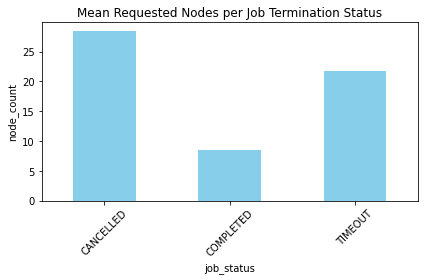

In [6]:
# Plot the graph
import matplotlib.pyplot as plt
mean_nodes_per_status.plot(kind='bar', color='skyblue')
plt.xlabel("job_status")
plt.ylabel("node_count")
plt.title("Mean Requested Nodes per Job Termination Status")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [7]:
mean_tasks_per_status = df.groupby("job_status")["tasks_requested"].mean()

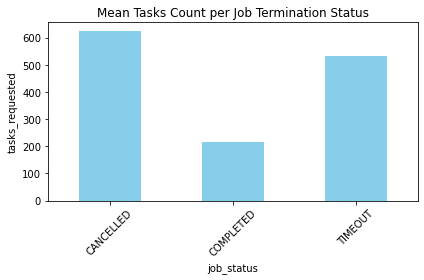

In [8]:
# Plot the graph
mean_tasks_per_status.plot(kind='bar', color='skyblue')
plt.xlabel("job_status")
plt.ylabel("tasks_requested")
plt.title("Mean Tasks Count per Job Termination Status")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
default_datetime = pd.to_datetime(0, unit='s') 
df['submit_time'].fillna(default_datetime, inplace=True)
df['start_time'].fillna(default_datetime, inplace=True)

df['timesub_numeric'] = pd.to_datetime(df['submit_time']).apply(lambda x: x.timestamp())
df['timesta_numeric'] = pd.to_datetime(df['start_time']).apply(lambda x: x.timestamp())  


X = df[['user_ID', 'group_ID', 'node_count', 'tasks_requested', 'timesub_numeric', 'timesta_numeric']]
y = df['job_status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

class_mapping = {'COMPLETED': 0, 'CANCELLED': 1, 'TIMEOUT': 2}
y_train_encoded = [class_mapping[label] for label in y_train]
y_test_encoded = [class_mapping[label] for label in y_test]

y_train_encoded = np.array(y_train_encoded)
y_test_encoded = np.array(y_test_encoded)

model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=0.0001)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2,callbacks=[early_stopping])

loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

Epoch 1/10
42264/42264 [==============================] - 253s 6ms/step - loss: 0.2845 - accuracy: 0.9057 - val_loss: 0.2882 - val_accuracy: 0.9069
Epoch 2/10
42264/42264 [==============================] - 226s 5ms/step - loss: 0.2524 - accuracy: 0.9131 - val_loss: 0.2519 - val_accuracy: 0.9133
Epoch 3/10
42264/42264 [==============================] - 229s 5ms/step - loss: 0.2452 - accuracy: 0.9151 - val_loss: 0.2586 - val_accuracy: 0.9098
Epoch 4/10
42264/42264 [==============================] - 238s 6ms/step - loss: 0.2409 - accuracy: 0.9162 - val_loss: 0.2502 - val_accuracy: 0.9102
Epoch 5/10
42264/42264 [==============================] - 264s 6ms/step - loss: 0.2378 - accuracy: 0.9170 - val_loss: 0.2413 - val_accuracy: 0.9135
Epoch 6/10
42264/42264 [==============================] - 272s 6ms/step - loss: 0.2350 - accuracy: 0.9178 - val_loss: 0.2449 - val_accuracy: 0.9108
Epoch 7/10
42264/42264 [==============================] - 283s 7ms/step - loss: 0.2327 - accuracy: 0.9184 - val_

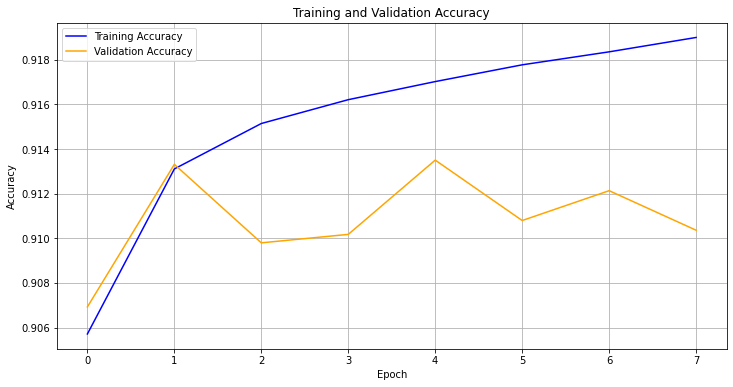

In [33]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

inverse_class_mapping = {v: k for k, v in class_mapping.items()}
y_test_original = [inverse_class_mapping[label] for label in y_test_encoded]
y_pred_original = [inverse_class_mapping[label] for label in y_pred]

print(classification_report(y_test_original, y_pred_original))

              precision    recall  f1-score   support

   CANCELLED       0.91      0.73      0.81     27154
   COMPLETED       0.92      0.99      0.95    364987
     TIMEOUT       0.69      0.17      0.27     30494

    accuracy                           0.91    422635
   macro avg       0.84      0.63      0.68    422635
weighted avg       0.90      0.91      0.89    422635



In [120]:
print(classsification_report(y_test,y_pred))

              Precision     Recall   F1-Score    Support
CANCELLED          0.83       0.86       0.84      27154
COMPLETED          0.97       0.98       0.97     364987
TIMEOUT            0.79       0.73       0.76      30494

   Macro avg       0.86       0.86       0.86     422635
Weighted avg       0.90       0.91       0.89     422635



In [93]:
ppp=joblib.load('alltreeMus.joblib')

In [35]:
import joblib
joblib.dump(model, 'allMust.joblib')

INFO:tensorflow:Assets written to: ram://061cfd88-72de-40d1-9b51-03fd6d8901d2/assets


['allMust.joblib']

In [ ]:
class_mapping = {'COMPLETED': 0, 'CANCELLED': 1, 'TIMEOUT': 2}
inverse_class_mapping = {v: k for k, v in class_mapping.items()}
predicted_labels = [inverse_class_mapping[label] for label in predicted_labels]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have your true labels and predicted labels
true_labels = y_test

# Calculate precision
precision = precision_score(true_labels, predicted_labels, average='weighted')

# Calculate recall
recall = recall_score(true_labels, predicted_labels, average='weighted')

# Calculate F1 score
f1 = f1_score(true_labels, predicted_labels, average='weighted')

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


In [7]:
import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2  
  
k_best = SelectKBest(score_func=chi2, k=5)  

X_selected = k_best.fit_transform(X, y)

selected_indices = k_best.get_support(indices=True)

selected_features = X.columns[selected_indices]

print("Selected features:", selected_features)


Selected features: Index(['user_ID', 'node_count', 'tasks_requested', 'timesub_numeric',
       'timesta_numeric'],
      dtype='object')


In [8]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression  

estimator = LogisticRegression()  

rfe = RFE(estimator, n_features_to_select=5)  

rfe.fit(X, y)

selected_indices = rfe.support_

selected_features = X.columns[selected_indices]

print("Selected features:", selected_features)


Selected features: Index(['user_ID', 'node_count', 'tasks_requested', 'timesub_numeric',
       'timesta_numeric'],
      dtype='object')


In [11]:
from scipy.stats import f_oneway

category_1_data = df[df['job_status'] == 'COMPLETED']['node_count']
category_2_data = df[df['job_status'] == 'CANCELLED']['node_count']
category_3_data = df[df['job_status'] == 'TIMEOUT']['node_count']

f_statistic, p_value = f_oneway(category_1_data, category_2_data,category_3_data)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

alpha = 0.05  
if p_value < alpha:
    print("The means of the node count are significantly different across job statuses.")
else:
    print("There is no significant difference in the means of the node count across job statuses.")


F-statistic: 16241.686443668223
p-value: 0.0
The means of the node count are significantly different across job statuses.


In [12]:
from scipy.stats import f_oneway

category_1_data = df[df['job_status'] == 'COMPLETED']['tasks_requested']
category_2_data = df[df['job_status'] == 'CANCELLED']['tasks_requested']
category_3_data = df[df['job_status'] == 'TIMEOUT']['tasks_requested']

f_statistic, p_value = f_oneway(category_1_data, category_2_data,category_3_data)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

alpha = 0.05  
if p_value < alpha:
    print("The means of the task requested are significantly different across job statuses.")
else:
    print("There is no significant difference in the means of the task requested across job statuses.")


F-statistic: 13416.336585893187
p-value: 0.0
The means of the task requested are significantly different across job statuses.


In [13]:
from scipy.stats import mannwhitneyu

group1 = df[df['job_status'] == 'CANCELLED']['tasks_requested']

group2 = df[df['job_status'] != 'CANCELLED']['tasks_requested']

statistic, p_value = mannwhitneyu(group1, group2)

print("Mann-Whitney U Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the distribution of numerical values between the specified category and other categories.")


Mann-Whitney U Statistic: 129158467297.5
P-value: 1.0715621338295026e-139
Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.


In [14]:
from scipy.stats import mannwhitneyu

group1 = df[df['job_status'] == 'CANCELLED']['node_count']

group2 = df[df['job_status'] != 'CANCELLED']['node_count']

statistic, p_value = mannwhitneyu(group1, group2)

print("Mann-Whitney U Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the distribution of numerical values between the specified category and other categories.")


Mann-Whitney U Statistic: 148557690989.5
P-value: 0.0
Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.


In [4]:
X = df[['user_ID', 'group_ID','node_count', 'tasks_requested', 'timesub_numeric', 'timesta_numeric']]
y = df['job_status']  

In [5]:
X_filtered = X[y.isin(['CANCELLED', 'COMPLETED', 'TIMEOUT'])]
y_filtered = y[y.isin(['CANCELLED', 'COMPLETED', 'TIMEOUT'])]

In [17]:
print(X_filtered.isna().sum())

user_ID            0
group_ID           0
node_count         0
tasks_requested    0
timesub_numeric    0
timesta_numeric    0
dtype: int64


In [59]:
import joblib
joblib.dump(clf, 'alltreeMus.joblib')#tasks

['alltreeMus.joblib']

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd


X = X_filtered[['tasks_requested']]
y = y_filtered

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8834810178996061


In [56]:
import joblib
joblib.dump(clf, 'tasktreeMus.joblib')#tasks

['tasktreeMus.joblib']

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd


X = X_filtered[['node_count']]
y = y_filtered

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8643510357637205


In [31]:
import joblib
joblib.dump(clf, 'nodetreeMus.joblib')#node

['nodetreeMus.joblib']

In [20]:
fail_rows = XX_filtered[XX_filtered['job_status'] == 'CANCELLED']
task_values_column = fail_rows['tasks_requested']
node_values_column = fail_rows['node_count']

In [21]:
sample_values = task_values_column.sample(n=5000, random_state=42)

In [6]:
XX = df[['user_ID', 'group_ID', 'node_count', 'tasks_requested', 'timesub_numeric', 'timesta_numeric','job_status']]
yy = df['job_status']  
XX_filtered = XX[yy.isin(['CANCELLED', 'COMPLETED', 'TIMEOUT'])]

In [23]:
def find_nearest_value_for_jobend(current_value, decision_tree):
    nearest_value = None
    min_distance = float('inf')
    
    def traverse_tree(node):
        nonlocal nearest_value, min_distance
        
        if decision_tree.tree_.children_left[node] == decision_tree.tree_.children_right[node]:
            if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'COMPLETED':
                threshold_value = decision_tree.tree_.threshold[node]
                distance = abs(current_value - threshold_value)
                if distance < min_distance:
                    nearest_value = threshold_value
                    min_distance = distance
            return
        
        feature_index = decision_tree.tree_.feature[node]
        threshold_value = decision_tree.tree_.threshold[node]
        
        if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'COMPLETED':
            if current_value <= threshold_value:
                traverse_tree(decision_tree.tree_.children_left[node])
            else:
                traverse_tree(decision_tree.tree_.children_right[node])
        
        distance = abs(current_value - threshold_value)
        if distance < min_distance:
            nearest_value = threshold_value
            min_distance = distance
    
    traverse_tree(0)
    
    return nearest_value


In [62]:
all_ranges = {status: [] for status in XX_filtered['job_status'].unique()}

df_sorted = XX_filtered.sort_values(by='tasks_requested')

prev_status = None
prev_node_count = None
for node_count, job_status in zip(df_sorted['tasks_requested'], df_sorted['job_status']):
    if prev_status is not None and job_status != prev_status:
        all_ranges[prev_status].append((prev_node_count, node_count))
    prev_status = job_status
    prev_node_count = node_count

merged_ranges = {status: [ranges[0]] for status, ranges in all_ranges.items()}
for status, ranges in all_ranges.items():
    for r in ranges[1:]:
        if r[1] == merged_ranges[status][-1][1]:
            merged_ranges[status][-1] = (merged_ranges[status][-1][0], r[1])
        else:
            merged_ranges[status].append(r)
            
fail_range = merged_ranges['CANCELLED']
end_range = merged_ranges['COMPLETED']
def calculate_threshold(range_list):
    thresholds = []
    for start, end in range_list:
        threshold = (start + end) / 2
        thresholds.append(threshold)  
    return thresholds

fail_thresholds = calculate_threshold(fail_range)

end_thresholds = calculate_threshold(end_range)
def find_nearest_threshold(value, thresholds, used_thresholds):
    min_distance = float('inf')
    nearest_threshold = None
    
    available_thresholds = [t for t in thresholds if t not in used_thresholds]
    
    if not available_thresholds:
        return None
    
    available_thresholds.sort(key=lambda x: abs(value - x))
    
    for threshold in available_thresholds:
        distance = abs(value - threshold)
        
        if distance < min_distance:
            min_distance = distance
            nearest_threshold = threshold
    
    used_thresholds.append(nearest_threshold)
    
    if nearest_threshold > value:
        lower_thresholds = [t for t in available_thresholds if t < value]
        if lower_thresholds:
            nearest_threshold = max(lower_thresholds)  
            used_thresholds.append(nearest_threshold)
    
    return nearest_threshold

In [24]:
def predict_category_with_optimal_value(df, row_index, numerical_column, decision_tree_model, optimal_numerical_value):
    df_clean = df.dropna()
    df_clean.loc[row_index, numerical_column] = optimal_numerical_value    
    predicted_category = decision_tree_model.predict(df_clean.loc[[row_index]])[0]
    
    return predicted_category


In [64]:
optimal_decision_tree_model = joblib.load('tasktreeMus.joblib')
prediction_decision_tree_model = joblib.load('alltreeMus.joblib')

In [65]:
def find_optimal_value_to_reach_finish(memory_values_column, optimal_decision_tree_model, prediction_decision_tree_model, thresholds, max_iterations):
    optimal_values = []
    used_thresholds = []
    for index, value_to_find in memory_values_column.iteritems():
        if pd.isnull(value_to_find):
            continue
        
        iterations = 0
        current_value = value_to_find
        while iterations < max_iterations:
            nearest_value_tree = find_nearest_value_for_jobend(current_value, optimal_decision_tree_model)
            if nearest_value_tree is not None:
                current_value = nearest_value_tree
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(X_filtered, index, 'tasks_requested', prediction_decision_tree_model, nearest_value_tree)
                if predicted_category == 'COMPLETED':
                    optimal_values.append(current_value)
                    break
            
            nearest_threshold = find_nearest_threshold(current_value, thresholds, used_thresholds)
            if nearest_threshold != current_value:
                current_value = nearest_threshold
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(X_filtered, index, 'tasks_requested', prediction_decision_tree_model, nearest_threshold)
                if predicted_category == 'COMPLETED':
                    optimal_values.append(current_value)
                    break
            
            iterations += 1

    return optimal_values

used_thresholds = []

optimal_values = find_optimal_value_to_reach_finish(sample_values, optimal_decision_tree_model, prediction_decision_tree_model, end_thresholds, 300) 
if optimal_values:
    print("Number of optimal values found:", len(optimal_values))

Number of optimal values found: 217


In [22]:
sample_values = node_values_column.sample(n=5000, random_state=42)

In [25]:
all_ranges = {status: [] for status in XX_filtered['job_status'].unique()}

df_sorted = XX_filtered.sort_values(by='node_count')

prev_status = None
prev_node_count = None
for node_count, job_status in zip(df_sorted['node_count'], df_sorted['job_status']):
    if prev_status is not None and job_status != prev_status:
        all_ranges[prev_status].append((prev_node_count, node_count))
    prev_status = job_status
    prev_node_count = node_count

merged_ranges = {status: [ranges[0]] for status, ranges in all_ranges.items()}
for status, ranges in all_ranges.items():
    for r in ranges[1:]:
        if r[1] == merged_ranges[status][-1][1]:
            merged_ranges[status][-1] = (merged_ranges[status][-1][0], r[1])
        else:
            merged_ranges[status].append(r)
            
fail_range = merged_ranges['CANCELLED']
end_range = merged_ranges['COMPLETED']
def calculate_threshold(range_list):
    thresholds = []
    for start, end in range_list:
        threshold = (start + end) / 2
        thresholds.append(threshold)  
    return thresholds

fail_thresholds = calculate_threshold(fail_range)

end_thresholds = calculate_threshold(end_range)
def find_nearest_threshold(value, thresholds, used_thresholds):
    min_distance = float('inf')
    nearest_threshold = None
    
    available_thresholds = [t for t in thresholds if t not in used_thresholds]
    
    if not available_thresholds:
        return None
    
    available_thresholds.sort(key=lambda x: abs(value - x))
    
    for threshold in available_thresholds:
        distance = abs(value - threshold)
        
        if distance < min_distance:
            min_distance = distance
            nearest_threshold = threshold
    
    used_thresholds.append(nearest_threshold)
    
    if nearest_threshold > value:
        lower_thresholds = [t for t in available_thresholds if t < value]
        if lower_thresholds:
            nearest_threshold = max(lower_thresholds)  
            used_thresholds.append(nearest_threshold)
    
    return nearest_threshold

In [32]:
import joblib
optimal_decision_tree_model = joblib.load('nodetreeMus.joblib')
prediction_decision_tree_model = joblib.load('alltreeMus.joblib')

In [33]:
def find_optimal_value_to_reach_finish(memory_values_column, optimal_decision_tree_model, prediction_decision_tree_model, thresholds, max_iterations):
    optimal_values = []
    used_thresholds = []
    for index, value_to_find in memory_values_column.iteritems():
        if pd.isnull(value_to_find):
            continue
        
        iterations = 0
        current_value = value_to_find
        while iterations < max_iterations:
            nearest_value_tree = find_nearest_value_for_jobend(current_value, optimal_decision_tree_model)
            if nearest_value_tree is not None:
                current_value = nearest_value_tree
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(X_filtered, index, 'node_count', prediction_decision_tree_model, nearest_value_tree)
                if predicted_category == 'COMPLETED':
                    optimal_values.append(current_value)
                    break
            
            nearest_threshold = find_nearest_threshold(current_value, thresholds, used_thresholds)
            if nearest_threshold != current_value:
                current_value = nearest_threshold
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(X_filtered, index, 'node_count', prediction_decision_tree_model, nearest_threshold)
                if predicted_category == 'COMPLETED':
                    optimal_values.append(current_value)
                    break
            
            iterations += 1

    return optimal_values

used_thresholds = []

optimal_values = find_optimal_value_to_reach_finish(sample_values, optimal_decision_tree_model, prediction_decision_tree_model, end_thresholds, 300) 
if optimal_values:
    print("Number of optimal values found:", len(optimal_values))

Number of optimal values found: 257


In [9]:
fail_rows=XX_filtered[XX_filtered['job_status'] == 'CANCELLED']

In [ ]:
import joblib

In [7]:
def preprocess_data(XX_filtered):
    end_range_tasks_requested = calculate_ranges(XX_filtered, 'tasks_requested')['COMPLETED']
    
    end_range_node_count = calculate_ranges(XX_filtered, 'node_count')['COMPLETED']
    
    return {
        'tasks_requested': {
            'end_range': end_range_tasks_requested
        },
        'node_count': {
            'end_range': end_range_node_count
        }
    }

def calculate_ranges(data, feature):
    all_ranges = {status: [] for status in data['job_status'].unique()}
    df_sorted = data.sort_values(by=feature)
    prev_status = None
    prev_value = None
    
    for value, status in zip(df_sorted[feature], df_sorted['job_status']):
        if prev_status is not None and status != prev_status:
            all_ranges[prev_status].append((prev_value, value))
        prev_status = status
        prev_value = value
    
    merged_ranges = {status: [ranges[0]] for status, ranges in all_ranges.items()}
    for status, ranges in all_ranges.items():
        for r in ranges[1:]:
            if r[1] == merged_ranges[status][-1][1]:
                merged_ranges[status][-1] = (merged_ranges[status][-1][0], r[1])
            else:
                merged_ranges[status].append(r)
    
    return merged_ranges


ranges_data = preprocess_data(XX_filtered)

end_range_tasks_requested = ranges_data['tasks_requested']['end_range']
end_range_node_count = ranges_data['node_count']['end_range']

def calculate_threshold(range_list):
    thresholds = []
    for start, end in range_list:
        threshold = int((start + end) / 2)
        thresholds.append(threshold)  
    return thresholds

end_thresholds_node_count = calculate_threshold(end_range_node_count)
end_thresholds_tasks_requested = calculate_threshold(end_range_tasks_requested)

In [10]:
import random
import joblib
import pandas as pd


def find_nearest_value_for_jobend(current_value, decision_tree):
    nearest_value = None
    min_distance = float('inf')
    
    def traverse_tree(node):
        nonlocal nearest_value, min_distance
        
        if decision_tree.tree_.children_left[node] == decision_tree.tree_.children_right[node]:
            if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'COMPLETED':
                threshold_value = decision_tree.tree_.threshold[node]
                distance = abs(current_value - threshold_value)
                if distance < min_distance:
                    nearest_value = threshold_value
                    min_distance = distance
            return
        
        feature_index = decision_tree.tree_.feature[node]
        threshold_value = decision_tree.tree_.threshold[node]
        
        if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'COMPLETED':
            if current_value <= threshold_value:
                traverse_tree(decision_tree.tree_.children_left[node])
            else:
                traverse_tree(decision_tree.tree_.children_right[node])
        
        distance = abs(current_value - threshold_value)
        if distance < min_distance:
            nearest_value = threshold_value
            min_distance = distance
    
    traverse_tree(0)
    
    return nearest_value






def find_nearest_threshold(value, thresholds, used_thresholds):
    min_distance = float('inf')
    nearest_threshold = None
    
    available_thresholds = [t for t in thresholds if t not in used_thresholds]
    
    if not available_thresholds:
        return None
    
    available_thresholds.sort(key=lambda x: abs(value - x))
    
    for threshold in available_thresholds:
        distance = abs(value - threshold)
        
        if distance < min_distance:
            min_distance = distance
            nearest_threshold = threshold
    
    used_thresholds.append(nearest_threshold)
    
    if nearest_threshold > value:
        lower_thresholds = [t for t in available_thresholds if t < value]
        if lower_thresholds:
            nearest_threshold = max(lower_thresholds)  
            used_thresholds.append(nearest_threshold)
    
    return nearest_threshold




def predict_category_with_optimal_value(df, row_index, numerical_column, decision_tree_model, optimal_numerical_value):
    df_clean = df.dropna()
    df_clean.loc[row_index, numerical_column] = optimal_numerical_value    
    predicted_category = decision_tree_model.predict(df_clean.loc[[row_index]])[0]
    
    return predicted_category





def find_optimal_value_to_reach_finish(value_to_find, job_index,optimal_decision_tree_model, prediction_model, thresholds, max_iterations, feature_column):
    optimal_values = []
    used_thresholds = []
    
    iterations = 0
    current_value = value_to_find
    while iterations < max_iterations:
        nearest_value_tree = find_nearest_value_for_jobend(current_value, optimal_decision_tree_model)
        if nearest_value_tree is not None:
            current_value = nearest_value_tree
            if pd.isnull(current_value):
                break
            predicted_category = predict_category_with_optimal_value(X_filtered, job_index, feature_column, prediction_model, nearest_value_tree)
            if predicted_category == 'COMPLETED':
                return current_value
        
        nearest_threshold = find_nearest_threshold(current_value, thresholds, used_thresholds)
        if nearest_threshold != current_value:
            current_value = nearest_threshold
            if pd.isnull(current_value):
                break
            predicted_category = predict_category_with_optimal_value(X_filtered, job_index, feature_column, prediction_model, nearest_threshold)
            if predicted_category == 'COMPLETED':
                return current_value
        
        iterations += 1

    return None





def find_optimal_value_for_feature(job, feature, job_index):
    optimal_value = None
    
    if feature == 'tasks_requested':
        optimal_decision_tree_model = joblib.load('tasktreeMus.joblib')
        prediction_model = joblib.load('alltreeMus.joblib')
        optimal_value = find_optimal_value_to_reach_finish(job['tasks_requested'], job_index,optimal_decision_tree_model, prediction_model, end_thresholds_tasks_requested, 300, 'tasks_requested')
    elif feature == 'node_count':
        optimal_decision_tree_model = joblib.load('nodetreeMus.joblib')
        prediction_model = joblib.load('alltreeMus.joblib')
        optimal_value = find_optimal_value_to_reach_finish(job['node_count'], job_index,optimal_decision_tree_model, prediction_model, end_thresholds_node_count, 300, 'node_count')
    
    return optimal_value




def prioritize_features():
    prioritized_features = ['node_count', 'tasks_requested']
    
    return prioritized_features




def dynamic_feature_optimization(jobs):
    failed_jobs = []
    indices_to_drop = []
    total_jobs = len(jobs)

    for job_index, job in jobs.iterrows():
        prioritized_features = prioritize_features()
        processed_for_all = False

        for feature in prioritized_features:
            optimal_value = find_optimal_value_for_feature(job, feature, job_index)
            if optimal_value is not None:
                print("The job",job_index,"can reach termination status COMPLETED with feature:",feature,"from value",job[feature],"to",optimal_value)
                processed_for_all = True
                break

        if processed_for_all:
            indices_to_drop.append(job_index)
        else:
            failed_jobs.append(job)

    jobs.drop(indices_to_drop, inplace=True)

    total_failed_jobs = len(failed_jobs)
    print("total successful jobs:", total_jobs - total_failed_jobs)
    print("total failed jobs:", total_failed_jobs)









jobs = fail_rows.sample(n=10, random_state=30)

dynamic_feature_optimization(jobs)


The job 13301 can reach termination status COMPLETED with feature: node_count from value 300 to 25
The job 1450892 can reach termination status COMPLETED with feature: node_count from value 200 to 126.5
The job 1081926 can reach termination status COMPLETED with feature: node_count from value 9 to 3
The job 756028 can reach termination status COMPLETED with feature: node_count from value 1 to 0
total successful jobs: 4
total failed jobs: 6


In [ ]:
#google cluster dataset

In [1]:
import pandas as pd
import numpy as np
import joblib

In [2]:
url="Downloads/google/borg_traces_data.csv"
df = pd.read_csv(url, delimiter=",")

In [3]:
def min_max_normalize(value, min_val, max_val, new_min=0, new_max=11):
    normalized_value = ((value - min_val) / (max_val - min_val)) * (new_max - new_min) + new_min
    return int(np.round(normalized_value))
min_val = df['priority'].min()
max_val = df['priority'].max()
df['new_priority'] = df['priority'].apply(lambda x: min_max_normalize(x, min_val, max_val))

In [4]:
statuses = ["FINISH","EVICT", "FAIL"]
df_filtered = df[df['event'].isin(statuses)]
grouped = df_filtered.groupby(['new_priority', 'event']).size().unstack(fill_value=0)
ratios = grouped.div(grouped.sum(axis=1), axis=0)

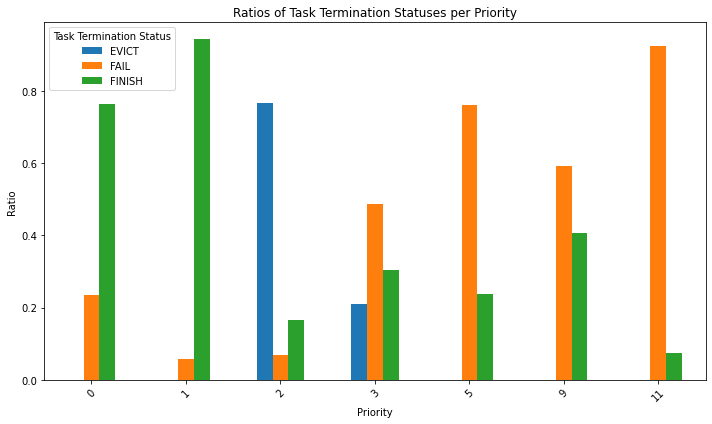

In [6]:
ratios.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Priority')
plt.ylabel('Ratio')
plt.title('Ratios of Task Termination Statuses per Priority')
plt.legend(title='Task Termination Status')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

In [7]:
statuses = ["EVICT", "FINISH", "FAIL"]
df_filtered = df[df['event'].isin(statuses)]
grouped = df_filtered.groupby(['scheduling_class', 'event']).size().unstack(fill_value=0)
ratios = grouped.div(grouped.sum(axis=1), axis=0)

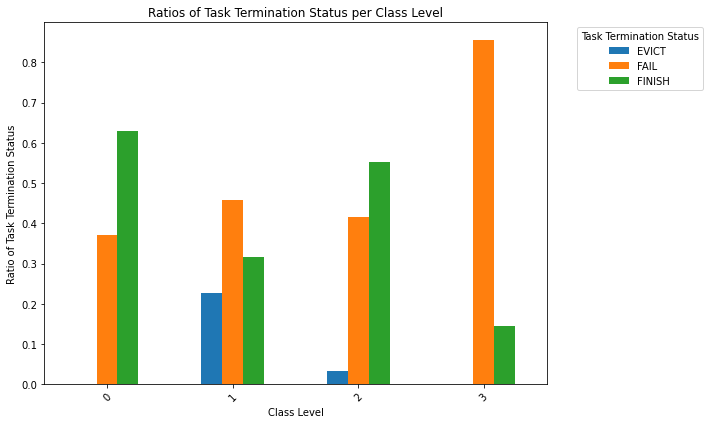

In [8]:
ratios.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Class Level')
plt.ylabel('Ratio of Task Termination Status')
plt.title('Ratios of Task Termination Status per Class Level')
plt.legend(title='Task Termination Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

In [12]:
statuses = ["EVICT", "FINISH", "FAIL"]
df_filtered = df1[df1['event'].isin(statuses)]
grouped = df_filtered.groupby(['cluster', 'event']).size().unstack(fill_value=0)
ratios = grouped.div(grouped.sum(axis=1), axis=0)

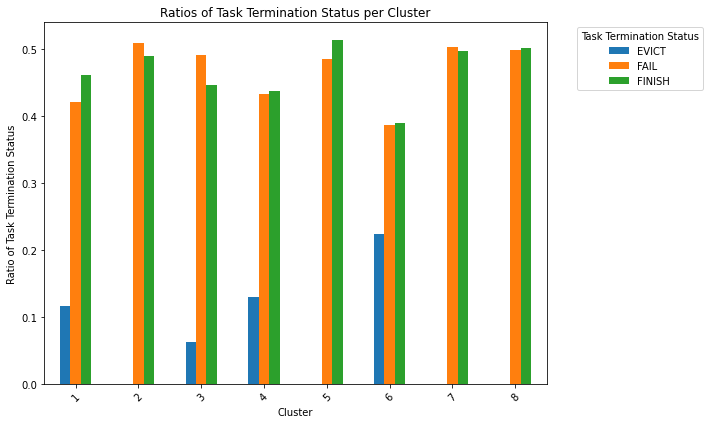

In [14]:
import matplotlib.pyplot as plt
ratios.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Cluster')
plt.ylabel('Ratio of Task Termination Status')
plt.title('Ratios of Task Termination Status per Cluster')
plt.legend(title='Task Termination Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

In [4]:
import ast
class_labels_to_consider = [ 'EVICT', 'FAIL', 'FINISH']

df = df[df['event'].isin(class_labels_to_consider)]

import numpy as np
def extract_cpu_memory_from_dataframe(df, resource_request):
    cpu_values = []
    memory_values = []
    for index, row in df.iterrows():
        if not pd.isna(row[resource_request]):  
            data_dict = ast.literal_eval(row[resource_request])
            cpu_values.append(data_dict['cpus'])
            memory_values.append(data_dict['memory'])
        else:
            cpu_values.append(np.nan)
            memory_values.append(np.nan)
    return cpu_values, memory_values

cpu_values, memory_values = extract_cpu_memory_from_dataframe(df, 'resource_request')

print("CPU Values:", cpu_values[:3])
print("Memory Values:", memory_values[:3])

CPU Values: [0.020660400390625, 0.00724029541015625, 0.0704345703125]
Memory Values: [0.014434814453125, 0.0013027191162109375, 0.0416259765625]


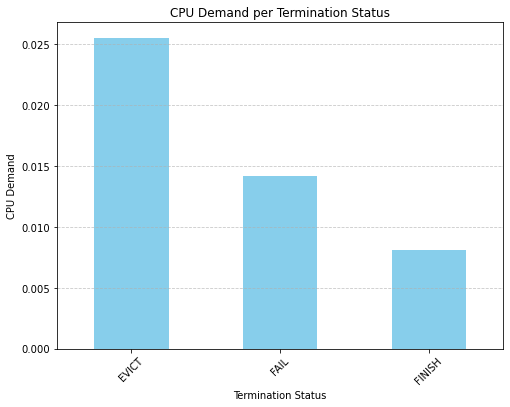

In [16]:
grouped = df.groupby('event')['cpu_values'].mean()

plt.figure(figsize=(8, 6))
grouped.plot(kind='bar', color='skyblue')
plt.title('CPU Demand per Termination Status')
plt.xlabel('Termination Status')
plt.ylabel('CPU Demand')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

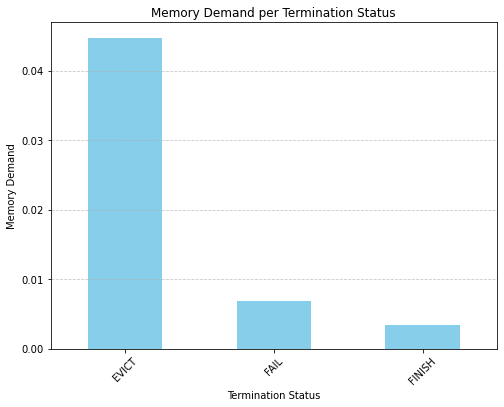

In [17]:
grouped = df.groupby('event')['memory_values'].mean()

plt.figure(figsize=(8, 6))
grouped.plot(kind='bar', color='skyblue')
plt.title('Memory Demand per Termination Status')
plt.xlabel('Termination Status')
plt.ylabel('Memory Demand')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [5]:
df['cpu_values'] = cpu_values
df['memory_values'] = memory_values
X = df[['machine_id', 'scheduling_class', 'priority', 'cpu_values', 'memory_values']]
y = df['event']  

In [6]:
X['cpu_values'].fillna(X['cpu_values'].mean(), inplace=True)
X['memory_values'].fillna(X['memory_values'].median(), inplace=True)
X['scheduling_class'].fillna(X['scheduling_class'].mode()[0], inplace=True)
X.dropna(inplace=True)

C:\Users\hp\anaconda3\lib\site-packages\pandas\core\generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)
C:\Users\hp\anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [7]:
df1 = pd.concat([X, df['event']], axis=1)
df1 = pd.concat([df1, df['cluster']], axis=1)
XX=pd.concat([X, df['cluster']], axis=1)
categories_to_include = ['FAIL', 'FINISH', 'EVICT']
filtered_df = df1[df1['event'].isin(categories_to_include)]

In [8]:
XX['cpu_values'].fillna(XX['cpu_values'].mean(), inplace=True)
XX['memory_values'].fillna(XX['memory_values'].median(), inplace=True)
XX['scheduling_class'].fillna(XX['scheduling_class'].mode()[0], inplace=True)
X.dropna(inplace=True)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

NameError: name 'train_test_split' is not defined

In [25]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

class_mapping = {'FINISH': 0, 'FAIL': 1, 'EVICT': 2}
y_train_encoded = [class_mapping[label] for label in y_train]
y_test_encoded = [class_mapping[label] for label in y_test]


#X_train_scaled = X_train_scaled.to_numpy() if isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled
y_train_encoded = np.array(y_train_encoded)
y_test_encoded = np.array(y_test_encoded)

In [26]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

try:
    history = model.fit(X_train_scaled, y_train_encoded, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

    loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded)
    print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

except Exception as e:
    print("An error occurred during training:")
    print(e)

Epoch 1/50
4006/4006 [==============================] - 16s 4ms/step - loss: 0.5615 - accuracy: 0.7213 - val_loss: 0.5050 - val_accuracy: 0.7628
Epoch 2/50
4006/4006 [==============================] - 14s 4ms/step - loss: 0.4746 - accuracy: 0.7772 - val_loss: 0.4469 - val_accuracy: 0.7858
Epoch 3/50
4006/4006 [==============================] - 14s 4ms/step - loss: 0.4398 - accuracy: 0.8008 - val_loss: 0.4263 - val_accuracy: 0.8142
Epoch 4/50
4006/4006 [==============================] - 14s 3ms/step - loss: 0.4226 - accuracy: 0.8142 - val_loss: 0.4207 - val_accuracy: 0.8107
Epoch 5/50
4006/4006 [==============================] - 14s 3ms/step - loss: 0.4095 - accuracy: 0.8235 - val_loss: 0.3990 - val_accuracy: 0.8315
Epoch 6/50
4006/4006 [==============================] - 14s 3ms/step - loss: 0.4002 - accuracy: 0.8286 - val_loss: 0.3949 - val_accuracy: 0.8278
Epoch 7/50
4006/4006 [==============================] - 14s 4ms/step - loss: 0.3924 - accuracy: 0.8327 - val_loss: 0.3863 - val_ac

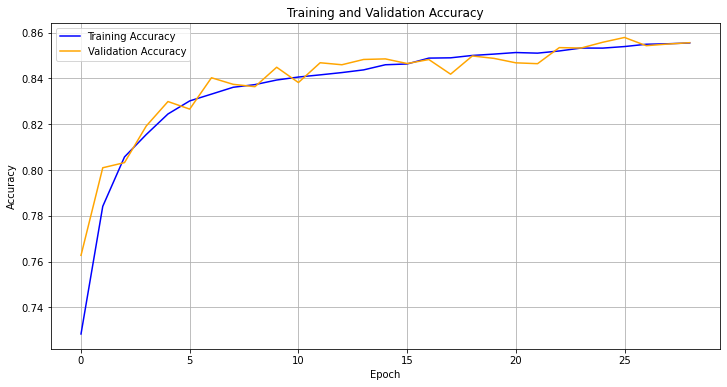

In [16]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

inverse_class_mapping = {v: k for k, v in class_mapping.items()}
y_test_original = [inverse_class_mapping[label] for label in y_test_encoded]
y_pred_original = [inverse_class_mapping[label] for label in y_pred]


print(classification_report(y_test_original, y_pred_original))

              precision    recall  f1-score   support

       EVICT       0.98      0.98      0.98      2919
        FAIL       0.86      0.83      0.85     18612
      FINISH       0.84      0.86      0.85     18530

    accuracy                           0.86     40061
   macro avg       0.89      0.89      0.89     40061
weighted avg       0.86      0.86      0.86     40061



In [27]:
predicted_labels=model.predict(X_test_scaled)

In [29]:
predicted_labels=np.argmax(predicted_labels, axis=1)
class_mapping = {'FINISH': 0, 'FAIL': 1, 'EVICT': 2}
inverse_class_mapping = {v: k for k, v in class_mapping.items()}
predicted_labels = [inverse_class_mapping[label] for label in predicted_labels]

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have your true labels and predicted labels
true_labels = y_test

# Calculate precision
precision = precision_score(true_labels, predicted_labels, average='weighted')

# Calculate recall
recall = recall_score(true_labels, predicted_labels, average='weighted')

# Calculate F1 score
f1 = f1_score(true_labels, predicted_labels, average='weighted')

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.8498186067596013
Recall: 0.8496043533611243
F1 Score: 0.8494655833794783


In [ ]:
import joblib
joblib.dump(clf, 'allgooglejob.joblib')#all

In [33]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
xx_scaled = scaler.fit_transform(XX)

k_best = SelectKBest(score_func=chi2, k=5)
X_selected = k_best.fit_transform(xx_scaled, y)

selected_indices = k_best.get_support(indices=True)

selected_features = XX.columns[selected_indices]

print("Selected features:", selected_features)

Selected features: Index(['scheduling_class', 'priority', 'cpu_values', 'memory_values',
       'cluster'],
      dtype='object')


In [34]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression  

estimator = LogisticRegression()  

rfe = RFE(estimator, n_features_to_select=5) 

rfe.fit(XX, y)

selected_indices = rfe.support_

selected_features = XX.columns[selected_indices]

print("Selected features:", selected_features)


Selected features: Index(['machine_id', 'scheduling_class', 'priority', 'cpu_values', 'cluster'], dtype='object')


In [35]:
from scipy.stats import f_oneway


category_1_data = df[df['event'] == 'FINISH']['scheduling_class']
category_2_data = df[df['event'] == 'EVICT']['scheduling_class']
category_3_data = df[df['event'] == 'FAIL']['scheduling_class']


f_statistic, p_value = f_oneway(category_1_data, category_2_data,category_3_data)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

alpha = 0.05  # Significance level
if p_value < alpha:
    print("The means of the scheduling class are significantly different across job statuses.")
else:
    print("There is no significant difference in the means of the scheduling class across job statuses.")


F-statistic: 3393.062515042057
p-value: 0.0
The means of the scheduling class are significantly different across job statuses.


In [36]:
from scipy.stats import f_oneway


category_1_data = df1[df1['event'] == 'FINISH']['memory_values']
category_2_data = df1[df1['event'] == 'EVICT']['memory_values']
category_3_data = df1[df1['event'] == 'FAIL']['memory_values']


f_statistic, p_value = f_oneway(category_1_data, category_2_data,category_3_data)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

alpha = 0.05  # Significance level
if p_value < alpha:
    print("The means of the memory values are significantly different across job statuses.")
else:
    print("There is no significant difference in the means of the memory values across job statuses.")


F-statistic: 26356.279751895694
p-value: 0.0
The means of the memory values are significantly different across job statuses.


In [37]:
from scipy.stats import f_oneway

category_1_data = df1[df1['event'] == 'FINISH']['cpu_values']
category_2_data = df1[df1['event'] == 'EVICT']['cpu_values']
category_3_data = df1[df1['event'] == 'FAIL']['cpu_values']


f_statistic, p_value = f_oneway(category_1_data, category_2_data,category_3_data)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

alpha = 0.05  # Significance level
if p_value < alpha:
    print("The means of the cpu values are significantly different across job statuses.")
else:
    print("There is no significant difference in the means of the cpu values across job statuses.")


F-statistic: 7792.08250357176
p-value: 0.0
The means of the cpu values are significantly different across job statuses.


In [38]:
from scipy.stats import f_oneway

category_1_data = df1[df1['event'] == 'FINISH']['cluster']
category_2_data = df1[df1['event'] == 'EVICT']['cluster']
category_3_data = df1[df1['event'] == 'FAIL']['cluster']


f_statistic, p_value = f_oneway(category_1_data, category_2_data,category_3_data)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

alpha = 0.05  # Significance level
if p_value < alpha:
    print("The means of the clusters are significantly different across job statuses.")
else:
    print("There is no significant difference in the means of the clusters across job statuses.")


F-statistic: 157.09478505478992
p-value: 6.730624556493273e-69
The means of the clusters are significantly different across job statuses.


In [40]:
from scipy.stats import mannwhitneyu

group1 = df[df['event'] == 'FAIL']['scheduling_class']

group2 = df[df['event'] != 'FAIL']['scheduling_class']

statistic, p_value = mannwhitneyu(group1, group2)

print("Mann-Whitney U Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the distribution of numerical values between the specified category and other categories.")


Mann-Whitney U Statistic: 5921422747.5
P-value: 0.0
Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.


In [9]:
from scipy.stats import mannwhitneyu

group1 = df1[df1['event'] == 'FAIL']['memory_values']

group2 = df1[df1['event'] != 'FAIL']['memory_values']

statistic, p_value = mannwhitneyu(group1, group2)

print("Mann-Whitney U Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category FAIL of memory demand and other categories of memory demand.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the distribution of numerical values between the specified category and other categories.")


Mann-Whitney U Statistic: 5803534864.5
P-value: 0.0
Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category FAIL of memory demand and other categories of memory demand.


In [42]:
from scipy.stats import mannwhitneyu

group1 = df1[df1['event'] == 'FAIL']['cpu_values']

group2 = df1[df1['event'] != 'FAIL']['cpu_values']

statistic, p_value = mannwhitneyu(group1, group2)

print("Mann-Whitney U Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the distribution of numerical values between the specified category and other categories.")


Mann-Whitney U Statistic: 5585307506.5
P-value: 0.0
Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.


In [43]:
from scipy.stats import mannwhitneyu

group1 = df1[df1['event'] == 'FAIL']['cluster']

group2 = df1[df1['event'] != 'FAIL']['cluster']

statistic, p_value = mannwhitneyu(group1, group2)

print("Mann-Whitney U Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the distribution of numerical values between the specified category and other categories.")


Mann-Whitney U Statistic: 5041002516.0
P-value: 2.5632278894421003e-05
Reject the null hypothesis: There is a significant difference in the distribution of numerical values between the specified category and other categories.


In [39]:
import joblib
joblib.dump(clf, 'googleall.joblib')#all

['googleall.joblib']

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd


categories_to_include = ['FAIL', 'FINISH', 'EVICT']

filtered_df = df1[df1['event'].isin(categories_to_include)]

xx = filtered_df[['memory_values']]
yy = filtered_df['event']

X_train, X_test, y_train, y_test = train_test_split(xx, yy, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8103142707371259


In [49]:
import joblib
joblib.dump(clf, 'googlemem.joblib')#memory

['googlemem.joblib']

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd


categories_to_include = ['FAIL', 'FINISH', 'EVICT']

filtered_df = df1[df1['event'].isin(categories_to_include)]

xx = filtered_df[['cpu_values']]
yy = filtered_df['event']

X_train, X_test, y_train, y_test = train_test_split(xx, yy, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8054466937919672


In [52]:
import joblib
joblib.dump(clf, 'googlecpu.joblib')#cpu

['googlecpu.joblib']

In [74]:
#fail_rows = filtered_df[filtered_df['event'] == 'FAIL']
#cpu_values_column = fail_rows['cpu_values']
#memory_values_column = fail_rows['memory_values']

In [90]:
test_rows = filtered_df[filtered_df['event'] == 'FAIL']
test_rows = test_rows.drop(columns='event')

In [69]:
def predict_category_for_pairs(df, row_index, numerical_column1,numerical_column2 ,decision_tree_model, optimal_numerical_value1,optimal_numerical_value2):
    df_clean = df.dropna()
    df_clean.loc[row_index, numerical_column1] = optimal_numerical_value1 
    df_clean.loc[row_index, numerical_column2] = optimal_numerical_value2    
    predicted_category = decision_tree_model.predict(df_clean.loc[[row_index]])[0]
    
    return predicted_category


In [64]:
import pandas as pd

fail_df = df1[df1['event'] == 'FAIL']

fail_counts = fail_df.groupby('cluster').size().reset_index(name='fail_count')

total_counts = df1.groupby('cluster').size().reset_index(name='total_count')

cluster_counts = pd.merge(fail_counts, total_counts, on='cluster', how='inner')

cluster_counts['fail_ratio'] = cluster_counts['fail_count'] / cluster_counts['total_count']

sorted_clusters = cluster_counts.sort_values(by='fail_ratio', ascending=True)

sorted_cluster_values = sorted_clusters['cluster']

In [65]:
import pandas as pd

fail_counts = df1[df1['event'] == 'FAIL'].groupby('scheduling_class').size()

total_counts = df1.groupby('scheduling_class').size()

fail_ratio = fail_counts / total_counts

scheduling_class_df = pd.DataFrame({'scheduling_class': fail_ratio.index, 'fail_ratio': fail_ratio.values})

sorted_scheduling_class = scheduling_class_df.sort_values(by='fail_ratio', ascending=True)

sorted_scheduling_class_values = sorted_scheduling_class['scheduling_class']

In [97]:
sample_values = test_rows.sample(n=5000, random_state=42)

In [110]:
pairs_list = []

for cluster_value in sorted_cluster_values:
    for scheduling_class_value in sorted_scheduling_class_values:
        pairs_list.append((cluster_value, scheduling_class_value))

def find_cluster_class_optimal_pair(job_index, test_rows,cluster_col, scheduling_col, decision_tree, pairs_list):
    for cluster_value, scheduling_class_value in pairs_list:
        predicted_category = predict_category_for_pairs(test_rows,job_index, 'cluster', 'scheduling_class', decision_tree, cluster_value, scheduling_class_value)
        if predicted_category == 'FINISH':
            return (job_index, cluster_value, scheduling_class_value)
    else:
        return None

pairs_for_finish = []

for index in sample_values.index:
    pair_for_finish = find_cluster_class_optimal_pair(index, sample_values,'cluster', 'scheduling_class', pred_model, pairs_list)
    if pair_for_finish is not None:
        pairs_for_finish.append(pair_for_finish)

print(len(pairs_for_finish))


4122


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd


categories_to_include = ['FAIL', 'FINISH', 'EVICT']

filtered_df = df_clean[df_clean['event'].isin(categories_to_include)]
yy = filtered_df['event']

XX = filtered_df.drop(columns=['event'])


In [222]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(XX, yy, test_size=0.2, random_state=42)

# Create and train the decision tree classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict the categories for the test data
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Print classification report for more detailed evaluation
print("Classification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.922990514228657
Classification report:
               precision    recall  f1-score   support

       EVICT       1.00      1.00      1.00      2913
        FAIL       0.91      0.92      0.92     18459
      FINISH       0.92      0.91      0.92     18688

    accuracy                           0.92     40060
   macro avg       0.94      0.94      0.94     40060
weighted avg       0.92      0.92      0.92     40060



In [223]:
import joblib
joblib.dump(clf, 'allgoogle.joblib')#all

['allgoogle.joblib']

In [55]:
pred_model = joblib.load('allgoogle.joblib')

In [57]:
y_pred = pred_model.predict(XX)

In [61]:
X_predicted_as_jobfail = X[y_pred == 'FAIL']
#X_predicted_as_jobfail_original = scaler.inverse_transform(X_predicted_as_jobfail)
fail_rows = pd.DataFrame(X_predicted_as_jobfail, columns=XX.columns)
memory_values_column = fail_rows['memory_values']
cpu_values_column = fail_rows['cpu_values']

In [117]:
optimal_decision_tree_model = joblib.load('googlemem.joblib')
prediction_model = joblib.load('allgoogle.joblib')

In [112]:
sample_values = memory_values_column.sample(n=5000, random_state=42)

In [113]:
def find_nearest_value_for_jobend(current_value, decision_tree):
    nearest_value = None
    min_distance = float('inf')
    
    def traverse_tree(node):
        nonlocal nearest_value, min_distance
        
        if decision_tree.tree_.children_left[node] == decision_tree.tree_.children_right[node]:
            if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'FINISH':
                threshold_value = decision_tree.tree_.threshold[node]
                distance = abs(current_value - threshold_value)
                if distance < min_distance:
                    nearest_value = threshold_value
                    min_distance = distance
            return
        
        feature_index = decision_tree.tree_.feature[node]
        threshold_value = decision_tree.tree_.threshold[node]
        
        if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'FINISH':
            if current_value <= threshold_value:
                traverse_tree(decision_tree.tree_.children_left[node])
            else:
                traverse_tree(decision_tree.tree_.children_right[node])
        
        distance = abs(current_value - threshold_value)
        if distance < min_distance:
            nearest_value = threshold_value
            min_distance = distance
    
    traverse_tree(0)
    
    return nearest_value


In [114]:
def predict_category_with_optimal_value(df, row_index, numerical_column, decision_tree_model, optimal_numerical_value):
    df_clean = df.dropna()
    df_clean.loc[row_index, numerical_column] = optimal_numerical_value    
    predicted_category = decision_tree_model.predict(df_clean.loc[[row_index]])[0]
    
    return predicted_category


In [115]:
all_ranges = {status: [] for status in filtered_df['event'].unique()}

df_sorted = filtered_df.sort_values(by='memory_values')

prev_status = None
prev_mem = None
for mem_val, job_status in zip(df_sorted['memory_values'], df_sorted['event']):
    if prev_status is not None and job_status != prev_status:
        all_ranges[prev_status].append((prev_mem, mem_val))
    prev_status = job_status
    prev_mem = mem_val

merged_ranges = {status: [ranges[0]] for status, ranges in all_ranges.items()}
for status, ranges in all_ranges.items():
    for r in ranges[1:]:
        if r[1] == merged_ranges[status][-1][1]:
            merged_ranges[status][-1] = (merged_ranges[status][-1][0], r[1])
        else:
            merged_ranges[status].append(r)
            
fail_range = merged_ranges['FAIL']
end_range = merged_ranges['FINISH']

def calculate_threshold(range_list):
    thresholds = []
    for start, end in range_list:
        threshold = (start + end) / 2
        thresholds.append(threshold)  
    return thresholds

fail_thresholds = calculate_threshold(fail_range)

end_thresholds = calculate_threshold(end_range)
def find_nearest_threshold(value, thresholds, used_thresholds):
    min_distance = float('inf')
    nearest_threshold = None
    
    available_thresholds = [t for t in thresholds if t not in used_thresholds]
    
    if not available_thresholds:
        return None
    
    available_thresholds.sort(key=lambda x: abs(value - x))
    
    for threshold in available_thresholds:
        distance = abs(value - threshold)
        
        if distance < min_distance:
            min_distance = distance
            nearest_threshold = threshold
    
    used_thresholds.append(nearest_threshold)
    
    if nearest_threshold > value:
        lower_thresholds = [t for t in available_thresholds if t < value]
        if lower_thresholds:
            nearest_threshold = max(lower_thresholds)  
            used_thresholds.append(nearest_threshold)
    
    return nearest_threshold

In [118]:
def find_optimal_value_to_reach_finish(values_column, optimal_decision_tree_model, prediction_model, thresholds, max_iterations):
    optimal_values = []
    used_thresholds = []
    for index, value_to_find in values_column.iteritems():
        if pd.isnull(value_to_find):
            continue
        
        iterations = 0
        current_value = value_to_find
        while iterations < max_iterations:
            nearest_value_tree = find_nearest_value_for_jobend(current_value, optimal_decision_tree_model)
            if nearest_value_tree is not None:
                current_value = nearest_value_tree
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(XX, index, 'memory_values', prediction_model, nearest_value_tree)
                if predicted_category == 'FINISH':
                    optimal_values.append(current_value)
                    break
            
            nearest_threshold = find_nearest_threshold(current_value, thresholds, used_thresholds)
            if nearest_threshold != current_value:
                current_value = nearest_threshold
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(XX, index, 'memory_values', prediction_model, nearest_threshold)
                if predicted_category == 'FINISH':
                    optimal_values.append(current_value)
                    break
            
            iterations += 1

    return optimal_values

used_thresholds = []

optimal_values = find_optimal_value_to_reach_finish(sample_values, optimal_decision_tree_model, prediction_model, end_thresholds, 300) 
if optimal_values:
    print("Number of optimal values found:", len(optimal_values))

Number of optimal values found: 997


In [119]:
all_ranges = {status: [] for status in filtered_df['event'].unique()}

df_sorted = filtered_df.sort_values(by='cpu_values')

prev_status = None
prev_cpu = None
for cpu_val, job_status in zip(df_sorted['cpu_values'], df_sorted['event']):
    if prev_status is not None and job_status != prev_status:
        all_ranges[prev_status].append((prev_cpu, cpu_val))
    prev_status = job_status
    prev_cpu = cpu_val

merged_ranges = {status: [ranges[0]] for status, ranges in all_ranges.items()}
for status, ranges in all_ranges.items():
    for r in ranges[1:]:
        if r[1] == merged_ranges[status][-1][1]:
            merged_ranges[status][-1] = (merged_ranges[status][-1][0], r[1])
        else:
            merged_ranges[status].append(r)
            
fail_range = merged_ranges['FAIL']
end_range = merged_ranges['FINISH']

def calculate_threshold(range_list):
    thresholds = []
    for start, end in range_list:
        threshold = (start + end) / 2
        thresholds.append(threshold)  
    return thresholds

fail_thresholds = calculate_threshold(fail_range)

end_thresholds = calculate_threshold(end_range)
def find_nearest_threshold(value, thresholds, used_thresholds):
    min_distance = float('inf')
    nearest_threshold = None
    
    available_thresholds = [t for t in thresholds if t not in used_thresholds]
    
    if not available_thresholds:
        return None
    
    available_thresholds.sort(key=lambda x: abs(value - x))
    
    for threshold in available_thresholds:
        distance = abs(value - threshold)
        
        if distance < min_distance:
            min_distance = distance
            nearest_threshold = threshold
    
    used_thresholds.append(nearest_threshold)
    
    if nearest_threshold > value:
        lower_thresholds = [t for t in available_thresholds if t < value]
        if lower_thresholds:
            nearest_threshold = max(lower_thresholds)  
            used_thresholds.append(nearest_threshold)
    
    return nearest_threshold

In [120]:
optimal_decision_tree_model = joblib.load('googlecpu.joblib')
prediction_model = joblib.load('allgoogle.joblib')

In [121]:
sample_values = cpu_values_column.sample(n=5000, random_state=42)

In [122]:
def find_optimal_value_to_reach_finish(values_column, optimal_decision_tree_model, prediction_model, thresholds, max_iterations):
    optimal_values = []
    used_thresholds = []
    for index, value_to_find in values_column.iteritems():
        if pd.isnull(value_to_find):
            continue
        
        iterations = 0
        current_value = value_to_find
        while iterations < max_iterations:
            nearest_value_tree = find_nearest_value_for_jobend(current_value, optimal_decision_tree_model)
            if nearest_value_tree is not None:
                current_value = nearest_value_tree
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(XX, index, 'cpu_values', prediction_model, nearest_value_tree)
                if predicted_category == 'FINISH':
                    optimal_values.append(current_value)
                    break
            
            nearest_threshold = find_nearest_threshold(current_value, thresholds, used_thresholds)
            if nearest_threshold != current_value:
                current_value = nearest_threshold
                if pd.isnull(current_value):
                    break
                predicted_category = predict_category_with_optimal_value(XX, index, 'cpu_values', prediction_model, nearest_threshold)
                if predicted_category == 'FINISH':
                    optimal_values.append(current_value)
                    break
            
            iterations += 1

    return optimal_values

used_thresholds = []

optimal_values = find_optimal_value_to_reach_finish(sample_values, optimal_decision_tree_model, prediction_model, end_thresholds, 300) 
if optimal_values:
    print("Number of optimal values found:", len(optimal_values))

Number of optimal values found: 357


In [13]:
import random
import joblib
import pandas as pd


def find_nearest_value_for_jobend(current_value, decision_tree):
    nearest_value = None
    min_distance = float('inf')
    
    def traverse_tree(node):
        nonlocal nearest_value, min_distance
        
        if decision_tree.tree_.children_left[node] == decision_tree.tree_.children_right[node]:
            if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'FINISH':
                threshold_value = decision_tree.tree_.threshold[node]
                distance = abs(current_value - threshold_value)
                if distance < min_distance:
                    nearest_value = threshold_value
                    min_distance = distance
            return
        
        feature_index = decision_tree.tree_.feature[node]
        threshold_value = decision_tree.tree_.threshold[node]
        
        if decision_tree.classes_[np.argmax(decision_tree.tree_.value[node])] == 'FINISH':
            if current_value <= threshold_value:
                traverse_tree(decision_tree.tree_.children_left[node])
            else:
                traverse_tree(decision_tree.tree_.children_right[node])
        
        distance = abs(current_value - threshold_value)
        if distance < min_distance:
            nearest_value = threshold_value
            min_distance = distance
    
    traverse_tree(0)
    
    return nearest_value






def find_nearest_threshold(value, thresholds, used_thresholds):
    min_distance = float('inf')
    nearest_threshold = None
    
    available_thresholds = [t for t in thresholds if t not in used_thresholds]
    
    if not available_thresholds:
        return None
    
    available_thresholds.sort(key=lambda x: abs(value - x))
    
    for threshold in available_thresholds:
        distance = abs(value - threshold)
        
        if distance < min_distance:
            min_distance = distance
            nearest_threshold = threshold
    
    used_thresholds.append(nearest_threshold)
    
    if nearest_threshold > value:
        lower_thresholds = [t for t in available_thresholds if t < value]
        if lower_thresholds:
            nearest_threshold = max(lower_thresholds)  
            used_thresholds.append(nearest_threshold)
    
    return nearest_threshold




def predict_category_with_optimal_value(df, row_index, numerical_column, decision_tree_model, optimal_numerical_value):
    df_clean = df.dropna()
    df_clean.loc[row_index, numerical_column] = optimal_numerical_value    
    predicted_category = decision_tree_model.predict(df_clean.loc[[row_index]])[0]
    
    return predicted_category





def predict_category_for_pairs(df, row_index, numerical_column1,numerical_column2 ,decision_tree_model, optimal_numerical_value1,optimal_numerical_value2):
    df_clean = df.dropna()
    df_clean.loc[row_index, numerical_column1] = optimal_numerical_value1 
    df_clean.loc[row_index, numerical_column2] = optimal_numerical_value2    
    predicted_category = decision_tree_model.predict(df_clean.loc[[row_index]])[0]
    
    return predicted_category





def find_optimal_value_to_reach_finish(value_to_find, job_index,optimal_decision_tree_model, prediction_model, thresholds, max_iterations, feature_column):
    optimal_values = []
    used_thresholds = []
    
    iterations = 0
    current_value = value_to_find
    while iterations < max_iterations:
        nearest_value_tree = find_nearest_value_for_jobend(current_value, optimal_decision_tree_model)
        if nearest_value_tree is not None:
            current_value = nearest_value_tree
            if pd.isnull(current_value):
                break
            predicted_category = predict_category_with_optimal_value(XX, job_index, feature_column, prediction_model, nearest_value_tree)
            if predicted_category == 'FINISH':
                return current_value
        
        nearest_threshold = find_nearest_threshold(current_value, thresholds, used_thresholds)
        if nearest_threshold != current_value:
            current_value = nearest_threshold
            if pd.isnull(current_value):
                break
            predicted_category = predict_category_with_optimal_value(XX, job_index, feature_column, prediction_model, nearest_threshold)
            if predicted_category == 'FINISH':
                return current_value
        
        iterations += 1

    return None





def find_optimal_value_for_feature(job, feature, job_index):
    optimal_value = None
    
    if feature == 'memory_values':
        optimal_decision_tree_model = joblib.load('googlemem.joblib')
        prediction_model = joblib.load('allgoogle.joblib')
        optimal_value = find_optimal_value_to_reach_finish(job['memory_values'], job_index,optimal_decision_tree_model, prediction_model, end_thresholds_memory_values, 300, 'memory_values')
    elif feature == 'cpu_values':
        optimal_decision_tree_model = joblib.load('googlecpu.joblib')
        prediction_model = joblib.load('allgoogle.joblib')
        optimal_value = find_optimal_value_to_reach_finish(job['cpu_values'], job_index,optimal_decision_tree_model, prediction_model, end_thresholds_cpu_values, 300, 'cpu_values')
        
    elif feature == 'cluster':
        pairs_list = create_cluster_class_pairs(df1)
        pred_model = joblib.load('allgoogle.joblib')
        optimal_value = find_cluster_class_optimal_pair(job_index, XX,'cluster', 'scheduling_class', pred_model, pairs_list)
    
    return optimal_value





def find_cluster_class_optimal_pair(job_index, test_rows,cluster_col, scheduling_col, decision_tree, pairs_list):
    for cluster_value, scheduling_class_value in pairs_list:
        predicted_category = predict_category_for_pairs(test_rows,job_index, 'cluster', 'scheduling_class', decision_tree, cluster_value, scheduling_class_value)
        if predicted_category == 'FINISH':
            return (cluster_value, scheduling_class_value)
    else:
        return None




def prioritize_features():
    prioritized_features = ['cluster','memory_values','cpu_values']
    
    return prioritized_features




def dynamic_feature_optimization(jobs):
    failed_jobs = []
    indices_to_drop = []
    total_jobs = len(jobs)

    for job_index, job in jobs.iterrows():
        prioritized_features = prioritize_features()
        processed_for_all = False

        for feature in prioritized_features:
            optimal_value = find_optimal_value_for_feature(job, feature, job_index)
            if optimal_value is not None:
                if feature=='cluster':
                    print("The job",job_index,"can reach termination status FINISH with feature:",feature,"and scheduling_class value from",job['cluster'],",",job['scheduling_class'],"to",optimal_value)
                else:
                    print("The job",job_index,"can reach termination status FINISH with feature:",feature,"value from",job[feature],"to",optimal_value)
                processed_for_all = True
                break

        if processed_for_all:
            indices_to_drop.append(job_index)
        else:
            failed_jobs.append(job)

    jobs.drop(indices_to_drop, inplace=True)

    total_failed_jobs = len(failed_jobs)
    print("total successful jobs:", total_jobs - total_failed_jobs)
    print("total failed jobs:", total_failed_jobs)









jobs = fail_rows.sample(n=10, random_state=30)

dynamic_feature_optimization(jobs)


The job 311440 can reach termination status FINISH with feature: cluster and scheduling_class value from 8 , 0 to this (4, 0)
The job 27104 can reach termination status FINISH with feature: cluster and scheduling_class value from 8 , 2 to this (3, 0)
The job 111622 can reach termination status FINISH with feature: cluster and scheduling_class value from 8 , 1 to this (6, 0)
The job 27114 can reach termination status FINISH with feature: cluster and scheduling_class value from 8 , 0 to this (6, 0)
The job 264627 can reach termination status FINISH with feature: memory_values value from 0.0106201171875 to this 0.0078887939453125
The job 36637 can reach termination status FINISH with feature: cluster and scheduling_class value from 3 , 2 to this (3, 0)
The job 22975 can reach termination status FINISH with feature: cluster and scheduling_class value from 3 , 1 to this (6, 0)
The job 195804 can reach termination status FINISH with feature: cpu_values value from 0.0 to this 0.00478363037109

In [11]:
def preprocess_data(filtered_df):
    end_range_cpu_values = calculate_ranges(filtered_df, 'cpu_values')['FINISH']
    
    end_range_memory_values = calculate_ranges(filtered_df, 'memory_values')['FINISH']
    
    return {
        'memory_values': {
            'end_range': end_range_memory_values
        },
        'cpu_values': {
            'end_range': end_range_cpu_values
        }
    }




def calculate_ranges(data, feature):
    all_ranges = {status: [] for status in data['event'].unique()}
    df_sorted = data.sort_values(by=feature)
    prev_status = None
    prev_value = None
    
    for value, status in zip(df_sorted[feature], df_sorted['event']):
        if prev_status is not None and status != prev_status:
            all_ranges[prev_status].append((prev_value, value))
        prev_status = status
        prev_value = value
    
    merged_ranges = {status: [ranges[0]] for status, ranges in all_ranges.items()}
    for status, ranges in all_ranges.items():
        for r in ranges[1:]:
            if r[1] == merged_ranges[status][-1][1]:
                merged_ranges[status][-1] = (merged_ranges[status][-1][0], r[1])
            else:
                merged_ranges[status].append(r)
    
    return merged_ranges


ranges_data = preprocess_data(filtered_df)

end_range_memory_values = ranges_data['memory_values']['end_range']
end_range_cpu_values = ranges_data['cpu_values']['end_range']



def calculate_threshold(range_list):
    thresholds = []
    for start, end in range_list:
        threshold = (start + end) / 2
        thresholds.append(threshold)  
    return thresholds

end_thresholds_cpu_values = calculate_threshold(end_range_cpu_values)
end_thresholds_memory_values = calculate_threshold(end_range_memory_values)


def create_cluster_class_pairs(df1):
    fail_df = df1[df1['event'] == 'FAIL']
    fail_counts = fail_df.groupby('cluster').size().reset_index(name='fail_count')
    total_counts = df1.groupby('cluster').size().reset_index(name='total_count')
    cluster_counts = pd.merge(fail_counts, total_counts, on='cluster', how='inner')
    cluster_counts['fail_ratio'] = cluster_counts['fail_count'] / cluster_counts['total_count']
    sorted_clusters = cluster_counts.sort_values(by='fail_ratio', ascending=True)
    sorted_cluster_values = sorted_clusters['cluster']
    
    fail_counts = df1[df1['event'] == 'FAIL'].groupby('scheduling_class').size()
    total_counts = df1.groupby('scheduling_class').size()
    fail_ratio = fail_counts / total_counts
    scheduling_class_df = pd.DataFrame({'scheduling_class': fail_ratio.index, 'fail_ratio': fail_ratio.values})
    sorted_scheduling_class = scheduling_class_df.sort_values(by='fail_ratio', ascending=True)
    sorted_scheduling_class_values = sorted_scheduling_class['scheduling_class']
    
    pairs_list = []

    for cluster_value in sorted_cluster_values:
        for scheduling_class_value in sorted_scheduling_class_values:
            pairs_list.append((cluster_value, scheduling_class_value))
    
    return pairs_list

In [10]:
fail_rows = filtered_df[filtered_df['event'] == 'FAIL']